## Подготовка окружения

Импортируем библиотеки для таблиц, FITS-файлов и графиков, задаём базовые пути проекта и общий стиль рисунков. Эта ячейка не читает данные и не запускает тяжёлые вычисления.


In [18]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe
from matplotlib.colors import LogNorm, Normalize, TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator, MaxNLocator, MultipleLocator

from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.visualization import ImageNormalize, LogStretch, ZScaleInterval

try:
    import seaborn as sns
except ImportError:
    sns = None

PROJECT_ROOT = Path.cwd().parent
CODE_DIR = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
BATCH_DIR = CODE_DIR / "sbf2_batch_outputs"
FIG_DIR = CODE_DIR / "paper_figures"
FIG_DIR.mkdir(exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 400,
    "savefig.dpi": 400,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.linewidth": 0.9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
    "image.origin": "lower",
})

if sns is not None:
    sns.set_theme(context="paper", style="ticks")
    sns.set_palette("colorblind")


## Загрузка финальных SBF-результатов

Читаем итоговые продукты batch-пайплайна. Для ошибок используется финальный Jensen-like budget: `sbf2_jensen_like_error_budget.csv`, машинно-читаемая версия отчёта `sbf2_jensen_like_error_budget.md`. Рабочая колонка `sigma_mbar_150` берётся из `sigma_jensen_like_fast`, а не из старой консервативной `recommended_sigma_adopted`.


In [19]:
RESULTS_CSV = BATCH_DIR / "sbf2_batch_results.csv"
ERRORS_CSV = BATCH_DIR / "sbf2_jensen_like_error_budget.csv"
ERRORS_REPORT_MD = BATCH_DIR / "sbf2_jensen_like_error_budget.md"
TARGETS_CSV = CODE_DIR / "article_galaxies_jwst_f150w_selected.csv"

results = pd.read_csv(RESULTS_CSV)
errors = pd.read_csv(ERRORS_CSV)
targets = pd.read_csv(TARGETS_CSV)

print(f"Final errors source: {ERRORS_CSV.name}; report: {ERRORS_REPORT_MD.name}")

paper_df = results.merge(errors, on="galaxy", how="inner", suffixes=("_batch", "_err"))
paper_df = paper_df.merge(
    targets[["galaxy", "source_articles", "jwst_program", "expected_f150w_i2d"]],
    on="galaxy",
    how="left",
)

paper_df["sigma_mbar_150"] = paper_df["sigma_jensen_like_fast"]
paper_df["inner_outer_delta"] = paper_df["recommended_mbar_inner"] - paper_df["recommended_mbar_outer"]
paper_df["quality_flag"] = paper_df["warnings"].fillna("").replace("", "clean")
paper_df["Pr_over_P0_weighted"] = (
    paper_df["Pr_over_P0_inner"] * paper_df["weight_inner"]
    + paper_df["Pr_over_P0_outer"] * paper_df["weight_outer"]
) / (paper_df["weight_inner"] + paper_df["weight_outer"])

science_cols = [
    "galaxy",
    "mbar_150",
    "sigma_mbar_150",
    "color_F090W_F150W",
    "color_sigma_proxy",
    "recommended_mbar_inner",
    "recommended_mbar_outer",
    "inner_outer_delta",
    "sigma_Pk_jensen_weighted_annuli",
    "sigma_PSF_mag",
    "sigma_Pr_proxy_weighted",
    "sigma_bkg_mag",
    "sigma_ext_mag",
    "Pr_over_P0_weighted",
    "quality_flag",
]

science_df = paper_df[science_cols].sort_values("galaxy").reset_index(drop=True)
display(science_df)
print(f"Loaded {len(science_df)} galaxies")


Final errors source: sbf2_jensen_like_error_budget.csv; report: sbf2_jensen_like_error_budget.md


,galaxy,mbar_150,sigma_mbar_150,color_F090W_F150W,color_sigma_proxy,recommended_mbar_inner,recommended_mbar_outer,inner_outer_delta,sigma_Pk_jensen_weighted_annuli,sigma_PSF_mag,sigma_Pr_proxy_weighted,sigma_bkg_mag,sigma_ext_mag,Pr_over_P0_weighted,quality_flag
0,NGC 1380,27.887067,0.038249,0.412876,0.064510,27.958796,27.814715,0.144082,0.036957,0.007222,0.006688,0.000390,0.000391,0.023928,clean
1,NGC 1399,28.124865,0.097574,0.437995,0.114503,28.209567,27.942924,0.266643,0.097231,0.007136,0.002675,0.002944,0.000261,0.009744,clean
2,NGC 1404,28.004212,0.039295,0.476706,0.078693,28.063214,27.854670,0.208544,0.038551,0.007201,0.002451,0.000019,0.000195,0.008942,clean
3,NGC 1549,27.670490,0.020142,0.343769,0.092703,27.866264,27.489457,0.376807,0.017308,0.007262,0.006512,0.003302,0.000261,0.023424,truncated_file_warning
4,NGC 3379,26.653558,0.028678,0.352921,0.108882,26.781523,26.576172,0.205351,0.022820,0.007625,0.015596,0.000361,0.000391,0.054236,truncated_file_warning
5,NGC 4374,27.698256,0.023503,0.420977,0.103682,27.751969,27.538217,0.213751,0.022213,0.007049,0.002719,0.000716,0.001172,0.009913,clean
6,NGC 4406,27.487489,0.019286,0.305918,0.120560,27.605388,27.370727,0.234661,0.017491,0.007177,0.003775,0.000445,0.000261,0.013690,clean
7,NGC 4472,27.512608,0.035932,0.405187,0.085524,27.606464,27.458259,0.148205,0.033787,0.007421,0.009675,0.000915,0.000130,0.034250,clean
8,NGC 4486,27.599748,0.045764,0.463310,0.111122,27.668090,27.446357,0.221733,0.045132,0.006826,0.003264,0.000192,0.000391,0.011876,clean
9,NGC 4552,27.618028,0.033527,0.457985,0.108111,27.656551,27.474669,0.181882,0.032163,0.007287,0.005960,0.000133,0.000977,0.021378,clean


Loaded 14 galaxies


## Таблица для абсолютной калибровки

Создаём и обновляем `paper_calibration_input.csv`. В эту таблицу попадают наши измеренные `mbar_150`, Jensen-like ошибки, цвет, флаги качества и литературные модули расстояния из `literature_distance_moduli.csv`.

Главные новые величины:

- `Mbar_150 = mbar_150 - mu_lit` — абсолютная SBF-величина в F150W;
- `sigma_Mbar_150` — ошибка без общего systematic нуль-пункта TRGB;
- `sigma_Mbar_150_with_trgb_zp_sys` — та же ошибка, но с добавленным общим systematic нуль-пункта NGC 4258.

Для фита формы `Mbar(color)` используем ошибку без общего нуль-пункта, потому что общий systematic двигает все точки почти одинаково и не должен задавать относительные веса.


In [ ]:
CALIBRATION_INPUT_CSV = BATCH_DIR / "paper_calibration_input.csv"
LITERATURE_MU_CSV = BATCH_DIR / "literature_distance_moduli.csv"
TRGB_COMMON_ZP_SYS_MAG = 0.046

measured_cols = [
    "galaxy",
    "mbar_150",
    "sigma_mbar_150",
    "color_F090W_F150W",
    "color_sigma_proxy",
    "recommended_mbar_inner",
    "recommended_mbar_outer",
    "inner_outer_delta",
    "sigma_Pk_jensen_weighted_annuli",
    "sigma_PSF_mag",
    "sigma_Pr_proxy_weighted",
    "sigma_bkg_mag",
    "sigma_ext_mag",
    "Pr_over_P0_weighted",
    "quality_flag",
    "source_articles",
]

lit_cols = [
    "galaxy",
    "mu_lit",
    "sigma_mu_lit",
    "distance_lit_mpc",
    "sigma_distance_lit_mpc",
    "distance_method",
    "distance_source",
    "distance_reference",
    "mu_project_iv_thin",
    "sigma_project_iv_thin",
    "mu_project_iv_thick",
    "sigma_project_iv_thick",
    "mu_prior_lit",
    "sigma_mu_prior_lit",
    "prior_lit_source",
    "notes",
]

calibration_input = paper_df[measured_cols].copy()
lit_mu = pd.read_csv(LITERATURE_MU_CSV)
calibration_input = calibration_input.merge(lit_mu[lit_cols], on="galaxy", how="left")

calibration_input["Mbar_150"] = calibration_input["mbar_150"] - calibration_input["mu_lit"]
calibration_input["sigma_Mbar_150"] = np.sqrt(
    calibration_input["sigma_mbar_150"] ** 2 + calibration_input["sigma_mu_lit"] ** 2
)
calibration_input["sigma_Mbar_150_with_trgb_zp_sys"] = np.sqrt(
    calibration_input["sigma_Mbar_150"] ** 2 + TRGB_COMMON_ZP_SYS_MAG**2
)
calibration_input["fit_sample"] = np.where(calibration_input["quality_flag"].eq("clean"), "clean", "flagged")

ordered_cols = [
    *measured_cols,
    "mu_lit",
    "sigma_mu_lit",
    "distance_lit_mpc",
    "sigma_distance_lit_mpc",
    "distance_method",
    "distance_source",
    "distance_reference",
    "mu_project_iv_thin",
    "sigma_project_iv_thin",
    "mu_project_iv_thick",
    "sigma_project_iv_thick",
    "mu_prior_lit",
    "sigma_mu_prior_lit",
    "prior_lit_source",
    "notes",
    "Mbar_150",
    "sigma_Mbar_150",
    "sigma_Mbar_150_with_trgb_zp_sys",
    "fit_sample",
]
calibration_input = calibration_input[ordered_cols].sort_values("galaxy").reset_index(drop=True)
calibration_input.to_csv(CALIBRATION_INPUT_CSV, index=False)

show_cols = [
    "galaxy",
    "mbar_150",
    "sigma_mbar_150",
    "mu_lit",
    "sigma_mu_lit",
    "Mbar_150",
    "sigma_Mbar_150",
    "color_F090W_F150W",
    "quality_flag",
]
display(calibration_input[show_cols])
print(f"Loaded literature distances: {LITERATURE_MU_CSV}")
print(f"Saved calibration table: {CALIBRATION_INPUT_CSV}")


## Видимая SBF-величина и цвет

Этот график оставлен как sanity check, а не как основной результат. `mbar_150` содержит не только свойства звёздного населения, но и расстояние до галактики, поэтому прямой график `mbar_150` против цвета физически плохо интерпретируется. Для статьи главным будет график `Mbar_150 = mbar_150 - mu_lit` против цвета после добавления литературных расстояний.

Горизонтальные ошибки здесь намеренно не рисуются: `color_sigma_proxy` — это разброс цвета между annuli, а не полноценная фотометрическая ошибка точки. Если нарисовать его как `xerr`, график становится нечитаемым и методически вводит в заблуждение.


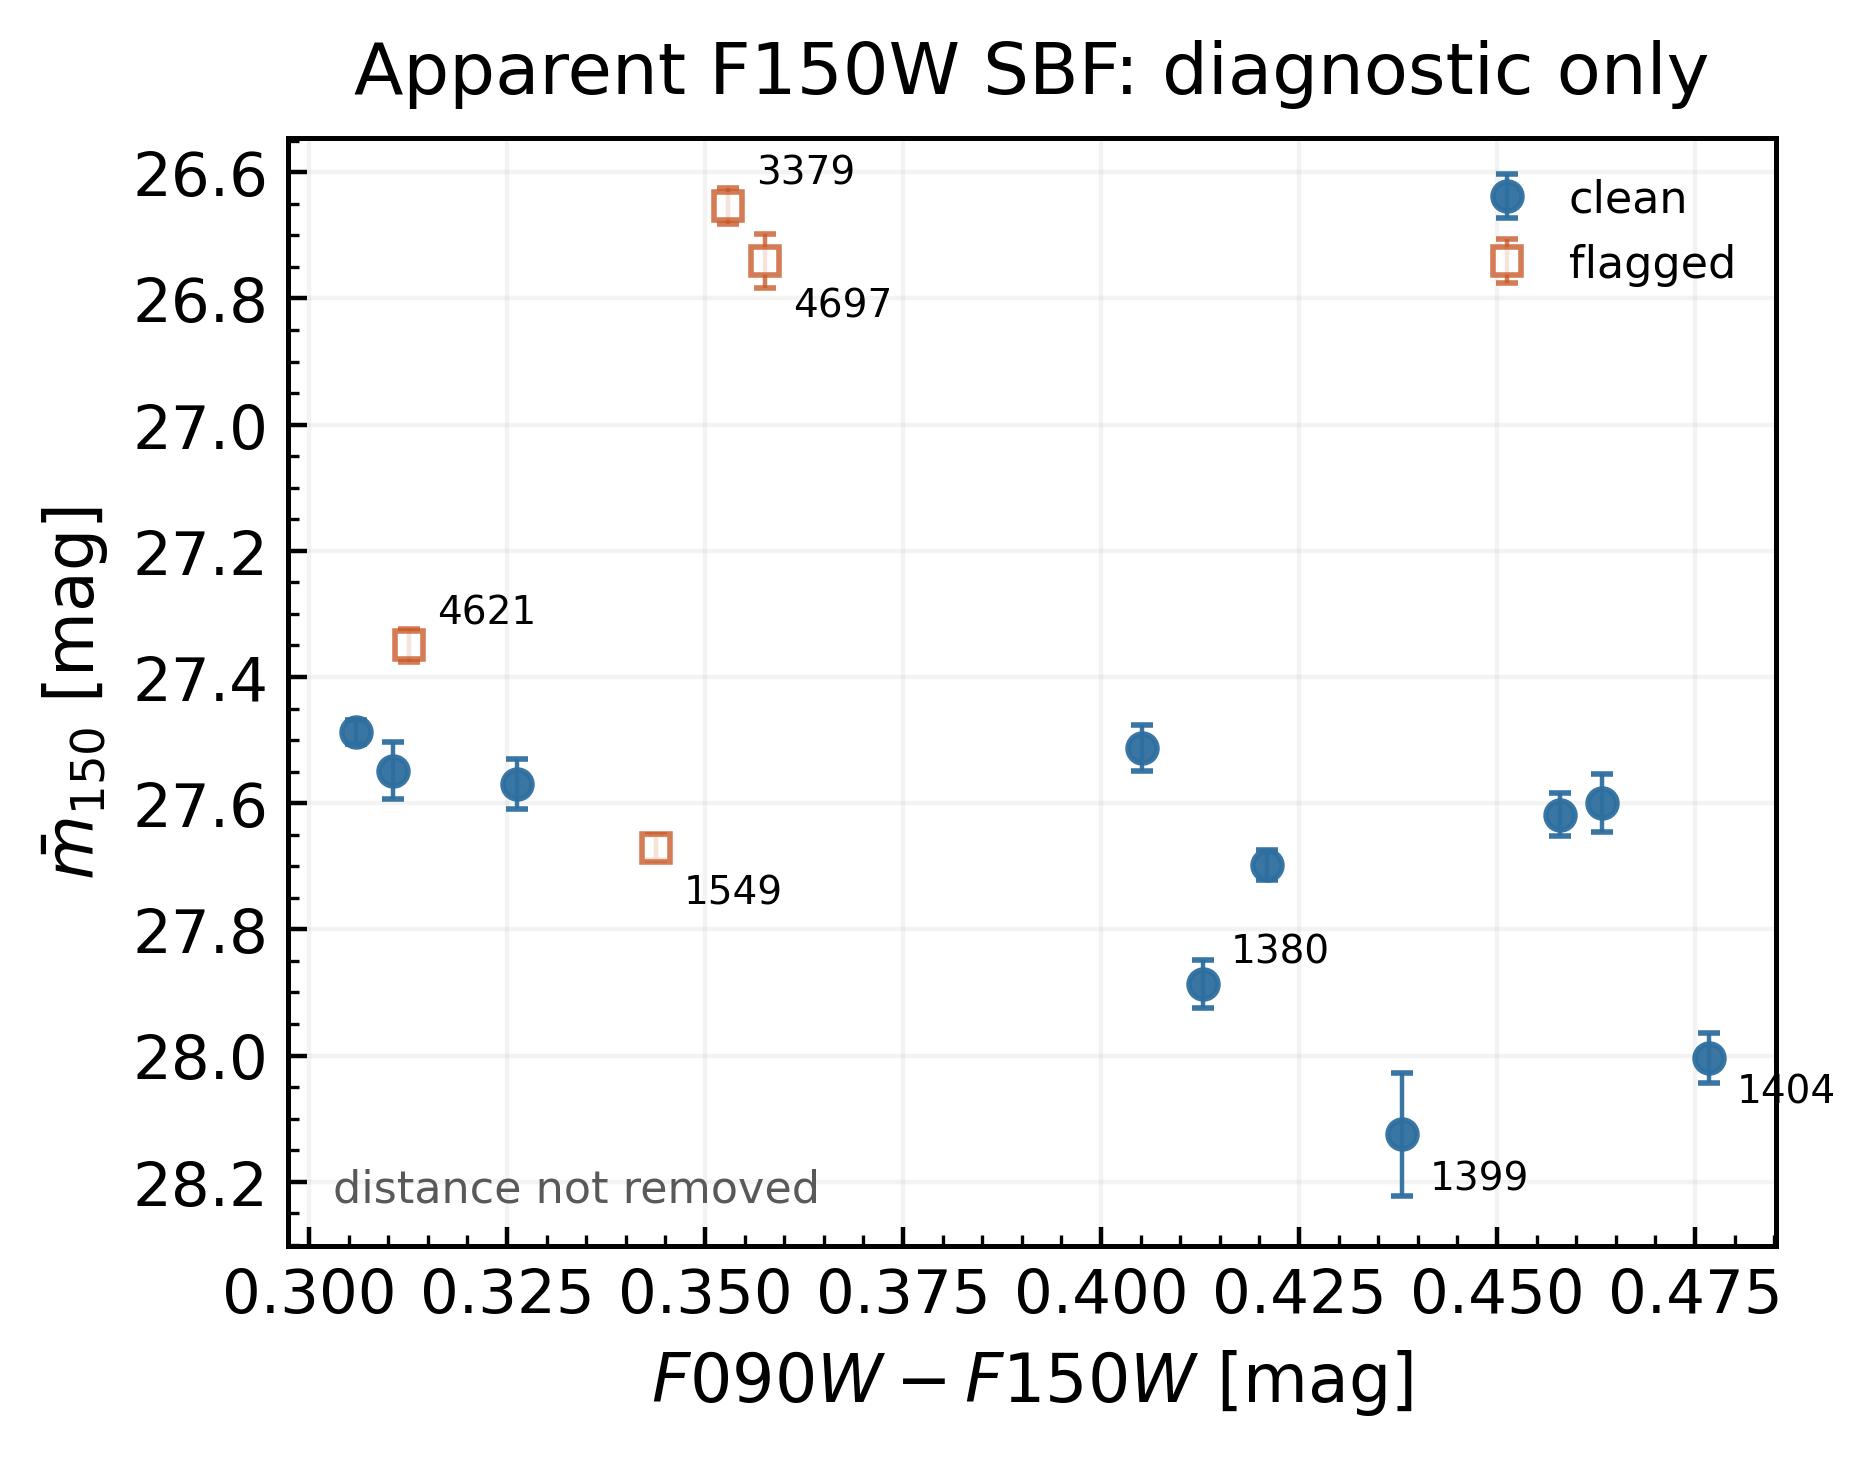

In [21]:
fig, ax = plt.subplots(figsize=(4.8, 3.6))

clean = science_df["quality_flag"].eq("clean")
styles = [
    (clean, "clean", "o", "#2f6f9f", 0.95),
    (~clean, "flagged", "s", "#c95b2b", 0.8),
]

for mask, label, marker, color, alpha in styles:
    sub = science_df[mask]
    ax.errorbar(
        sub["color_F090W_F150W"],
        sub["mbar_150"],
        yerr=sub["sigma_mbar_150"],
        fmt=marker,
        ms=5.2,
        capsize=2.0,
        lw=0.8,
        color=color,
        mec=color,
        mfc="white" if label == "flagged" else color,
        alpha=alpha,
        label=label,
    )

label_mask = (~clean) | science_df["galaxy"].isin(["NGC 1399", "NGC 1404", "NGC 1380"])
label_offsets = {
    "NGC 3379": (5, 4),
    "NGC 4697": (5, -10),
    "NGC 4621": (5, 4),
    "NGC 1549": (5, -10),
    "NGC 1399": (5, -10),
    "NGC 1404": (5, -8),
    "NGC 1380": (5, 4),
}
for _, row in science_df[label_mask].iterrows():
    dx, dy = label_offsets.get(row["galaxy"], (4, 3))
    ax.annotate(row["galaxy"].replace("NGC ", ""), (row["color_F090W_F150W"], row["mbar_150"]), xytext=(dx, dy), textcoords="offset points", fontsize=7)

ax.invert_yaxis()
ax.set_xlabel(r"$F090W - F150W$ [mag]")
ax.set_ylabel(r"$\bar m_{150}$ [mag]")
ax.set_title("Apparent F150W SBF: diagnostic only", pad=8)
ax.text(
    0.03,
    0.04,
    r"distance not removed",
    transform=ax.transAxes,
    fontsize=8,
    color="0.35",
)
ax.legend(loc="upper right", fontsize=8, handlelength=1.2)
ax.grid(alpha=0.14)
fig.savefig(FIG_DIR / "mbar150_vs_color_diagnostic.pdf")
fig.savefig(FIG_DIR / "mbar150_vs_color_diagnostic.png")
plt.show()


## Jensen-like бюджет ошибок

Показываем вклад независимых компонент в итоговую дисперсию `sigma_mbar_150^2`: `sigma_Pk`, `sigma_PSF`, `sigma_Pr`, `sigma_bkg`, `sigma_ext`. Рисунок сделан горизонтальным и отсортирован по итоговой ошибке, чтобы сразу было видно, что почти везде доминирует компонент `P(k)`.


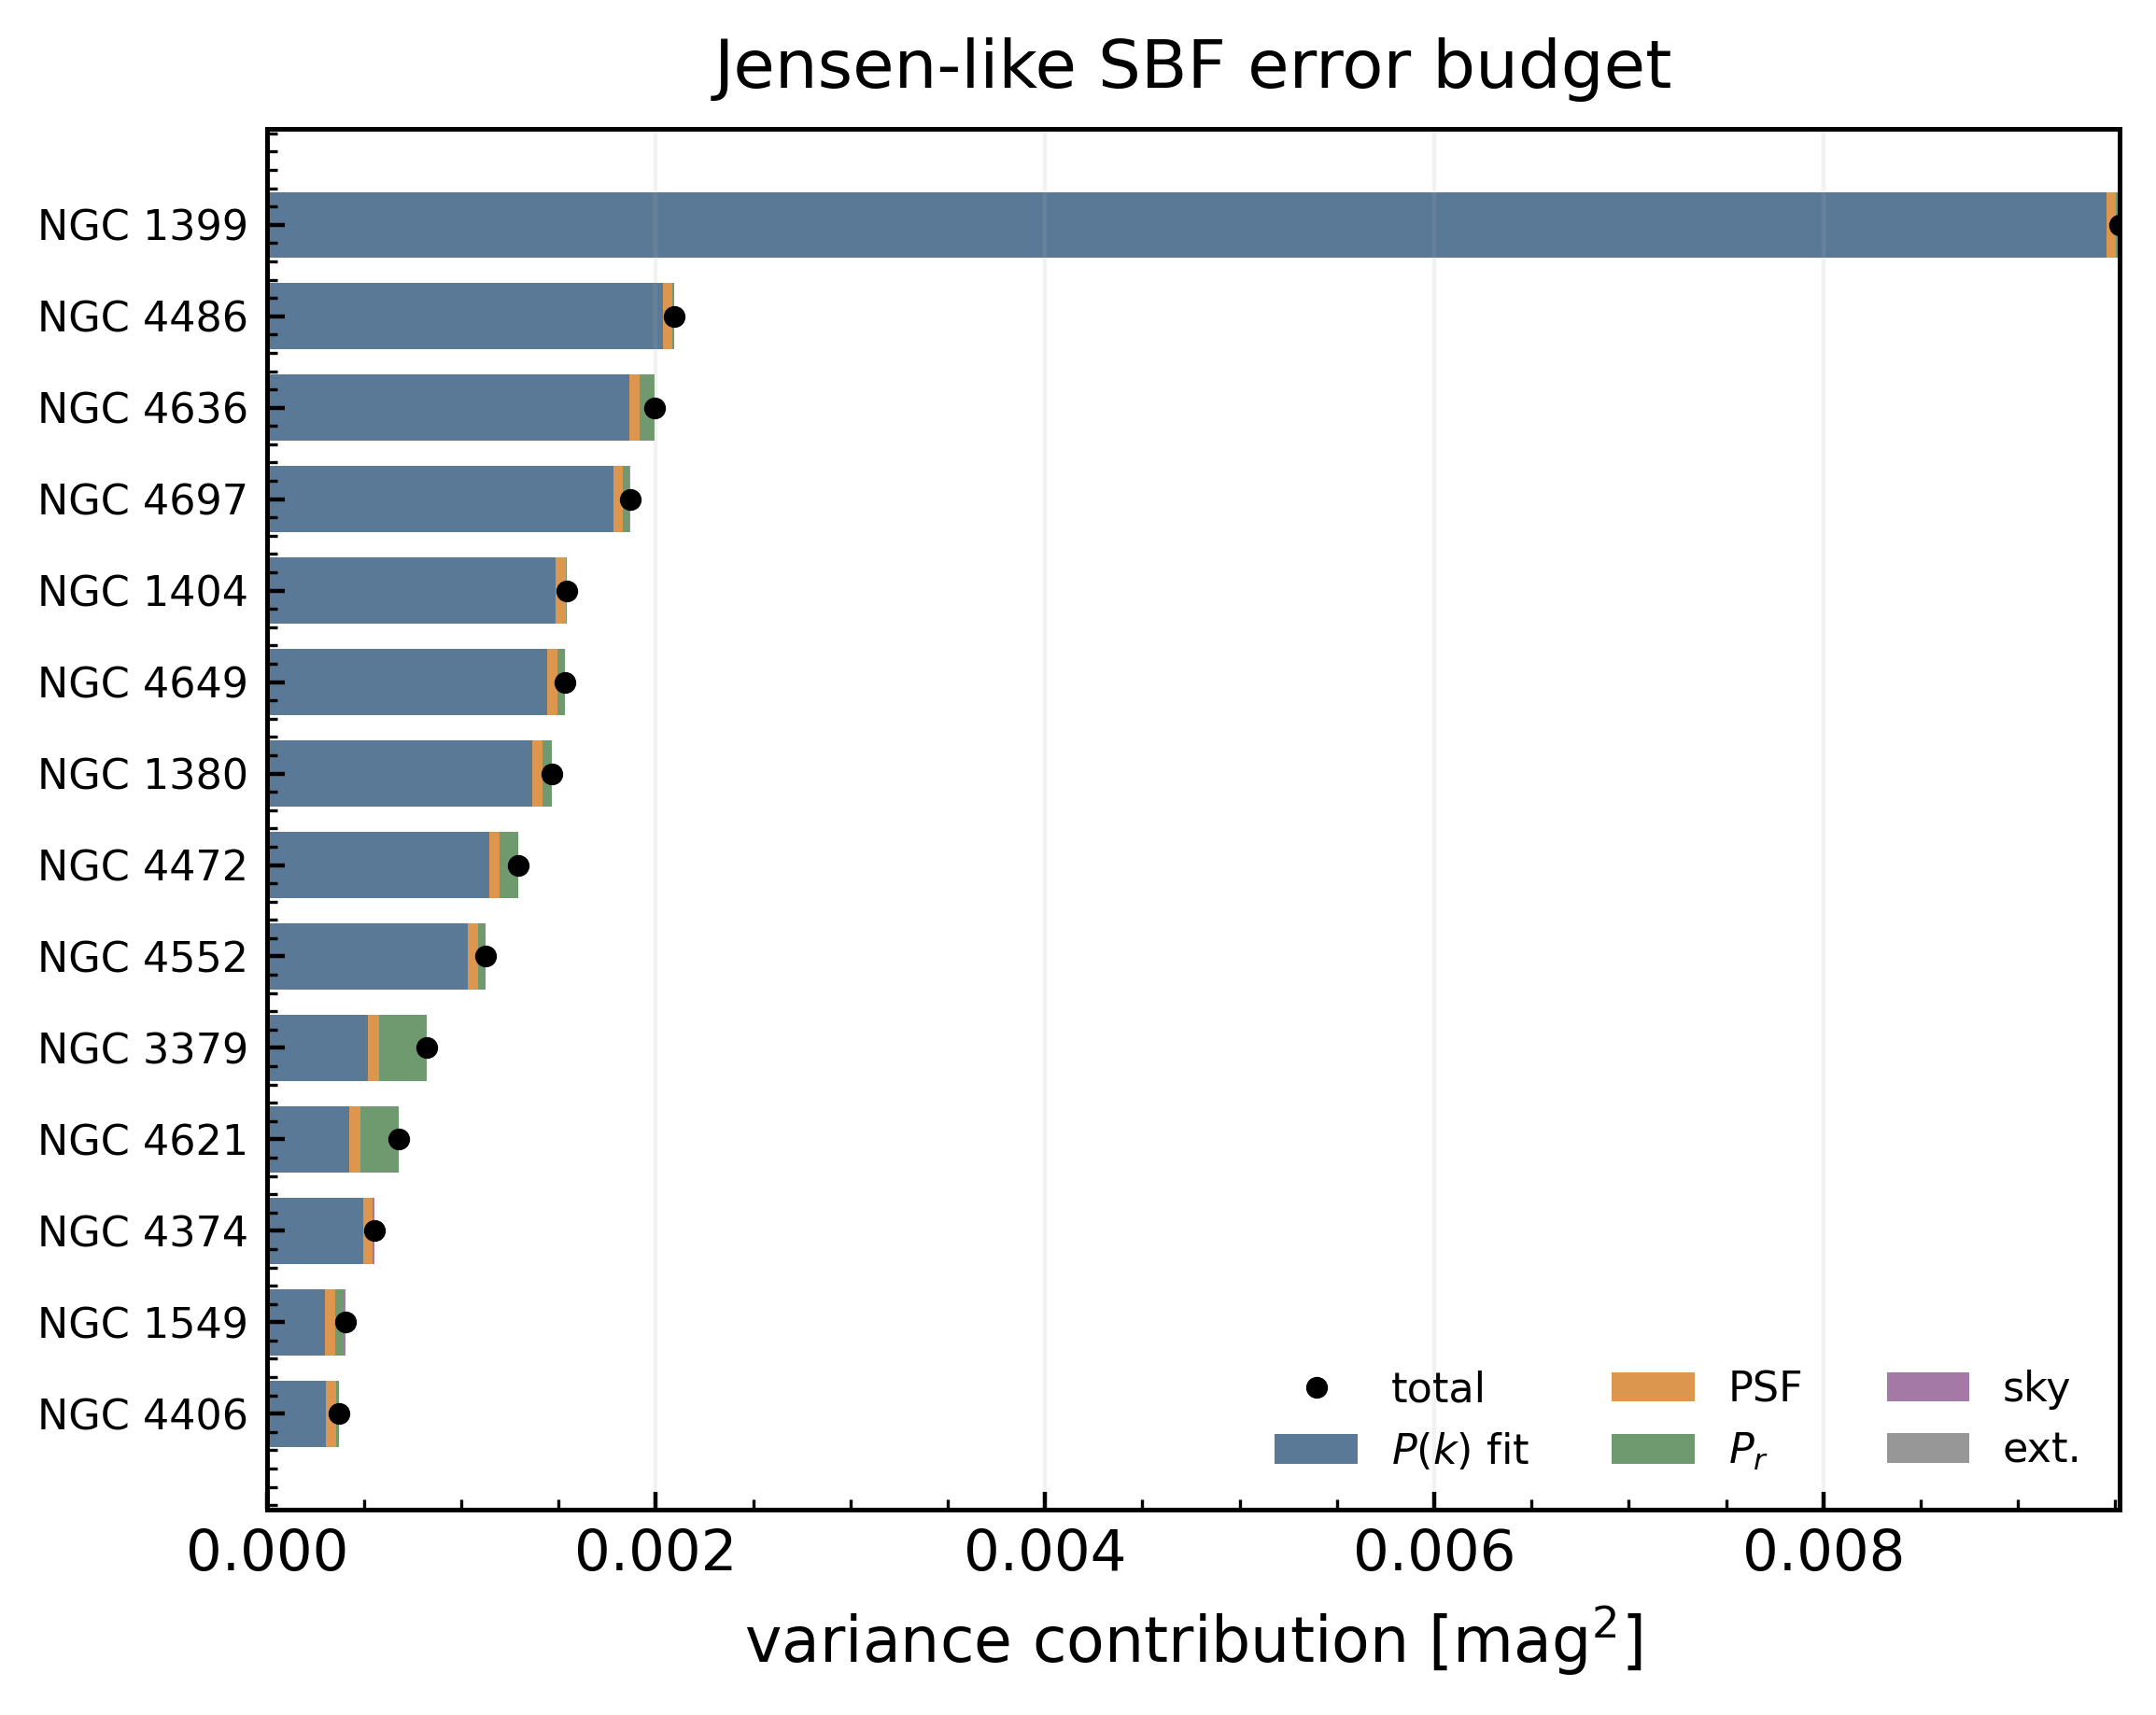

In [22]:
components = [
    ("sigma_Pk_jensen_weighted_annuli", r"$P(k)$ fit", "#486a8c"),
    ("sigma_PSF_mag", "PSF", "#d98b3a"),
    ("sigma_Pr_proxy_weighted", r"$P_r$", "#5f8f5f"),
    ("sigma_bkg_mag", "sky", "#9b6a9b"),
    ("sigma_ext_mag", "ext.", "#8c8c8c"),
]

budget_df = science_df.merge(errors[["galaxy", *[c for c, _, _ in components]]], on="galaxy", how="left", suffixes=("", "_err"))
budget_df = budget_df.sort_values("sigma_mbar_150", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(6.4, 4.8))
y = np.arange(len(budget_df))
left_var = np.zeros(len(budget_df))

for col, label, color in components:
    vals = budget_df[col].to_numpy(dtype=float)
    ax.barh(y, vals**2, left=left_var, height=0.72, label=label, color=color, alpha=0.9)
    left_var += vals**2

ax.plot(budget_df["sigma_mbar_150"] ** 2, y, color="black", marker="o", lw=0, ms=3.2, label=r"total")
ax.set_yticks(y)
ax.set_yticklabels(budget_df["galaxy"], fontsize=8)
ax.set_xlabel(r"variance contribution [mag$^2$]")
ax.set_title("Jensen-like SBF error budget", pad=8)
ax.legend(ncols=3, fontsize=8, loc="lower right")
ax.grid(axis="x", alpha=0.16)
fig.savefig(FIG_DIR / "jensen_like_error_budget_variance.pdf")
fig.savefig(FIG_DIR / "jensen_like_error_budget_variance.png")
plt.show()


## Сводка по частотным окнам

Собираем сохранённые `*_sbf2_annulus_summary.csv` для всех галактик. Это позволяет без пересчёта SBF сравнить результаты при `kmin=0.01`, `0.03` и `0.04`.


In [23]:
k_rows = []
for _, row in paper_df.iterrows():
    path = Path(row["annulus_summary_csv"])
    if not path.exists():
        continue
    ann = pd.read_csv(path)
    ann["galaxy"] = row["galaxy"]
    k_rows.append(ann)

k_summary = pd.concat(k_rows, ignore_index=True)
ref = k_summary[k_summary["kmin"].eq(0.04)][["galaxy", "mbar_weighted"]].rename(columns={"mbar_weighted": "mbar_ref"})
k_summary = k_summary.merge(ref, on="galaxy", how="left")
k_summary["delta_from_adopted"] = k_summary["mbar_weighted"] - k_summary["mbar_ref"]

display(k_summary[["galaxy", "kmin", "kmax", "mbar_weighted", "delta_from_adopted", "sigma_weighted_formal", "annulus_scatter"]])


,galaxy,kmin,kmax,mbar_weighted,delta_from_adopted,sigma_weighted_formal,annulus_scatter
0,NGC 1380,0.01,0.25,27.754595,-0.132471,0.026133,0.086196
1,NGC 1380,0.03,0.25,27.862140,-0.024927,0.026133,0.072095
2,NGC 1380,0.04,0.25,27.887067,0.000000,0.026133,0.072041
3,NGC 1399,0.01,0.25,27.790297,-0.334568,0.069968,0.248519
4,NGC 1399,0.03,0.25,28.059284,-0.065582,0.069968,0.146622
5,NGC 1399,0.04,0.25,28.124865,0.000000,0.069968,0.133322
6,NGC 1404,0.01,0.25,27.907012,-0.097200,0.029285,0.181598
7,NGC 1404,0.03,0.25,27.953733,-0.050478,0.027962,0.093798
8,NGC 1404,0.04,0.25,28.004212,0.000000,0.027962,0.104272
9,NGC 4472,0.01,0.25,27.444893,-0.067716,0.024110,0.068986


## Чувствительность результата к `kmin`

Показываем не отдельную линию для каждой галактики, а распределение смещений при разных `kmin`. Такой вид читается лучше: видно медиану, разброс и flagged-точки, но график не превращается в спагетти.


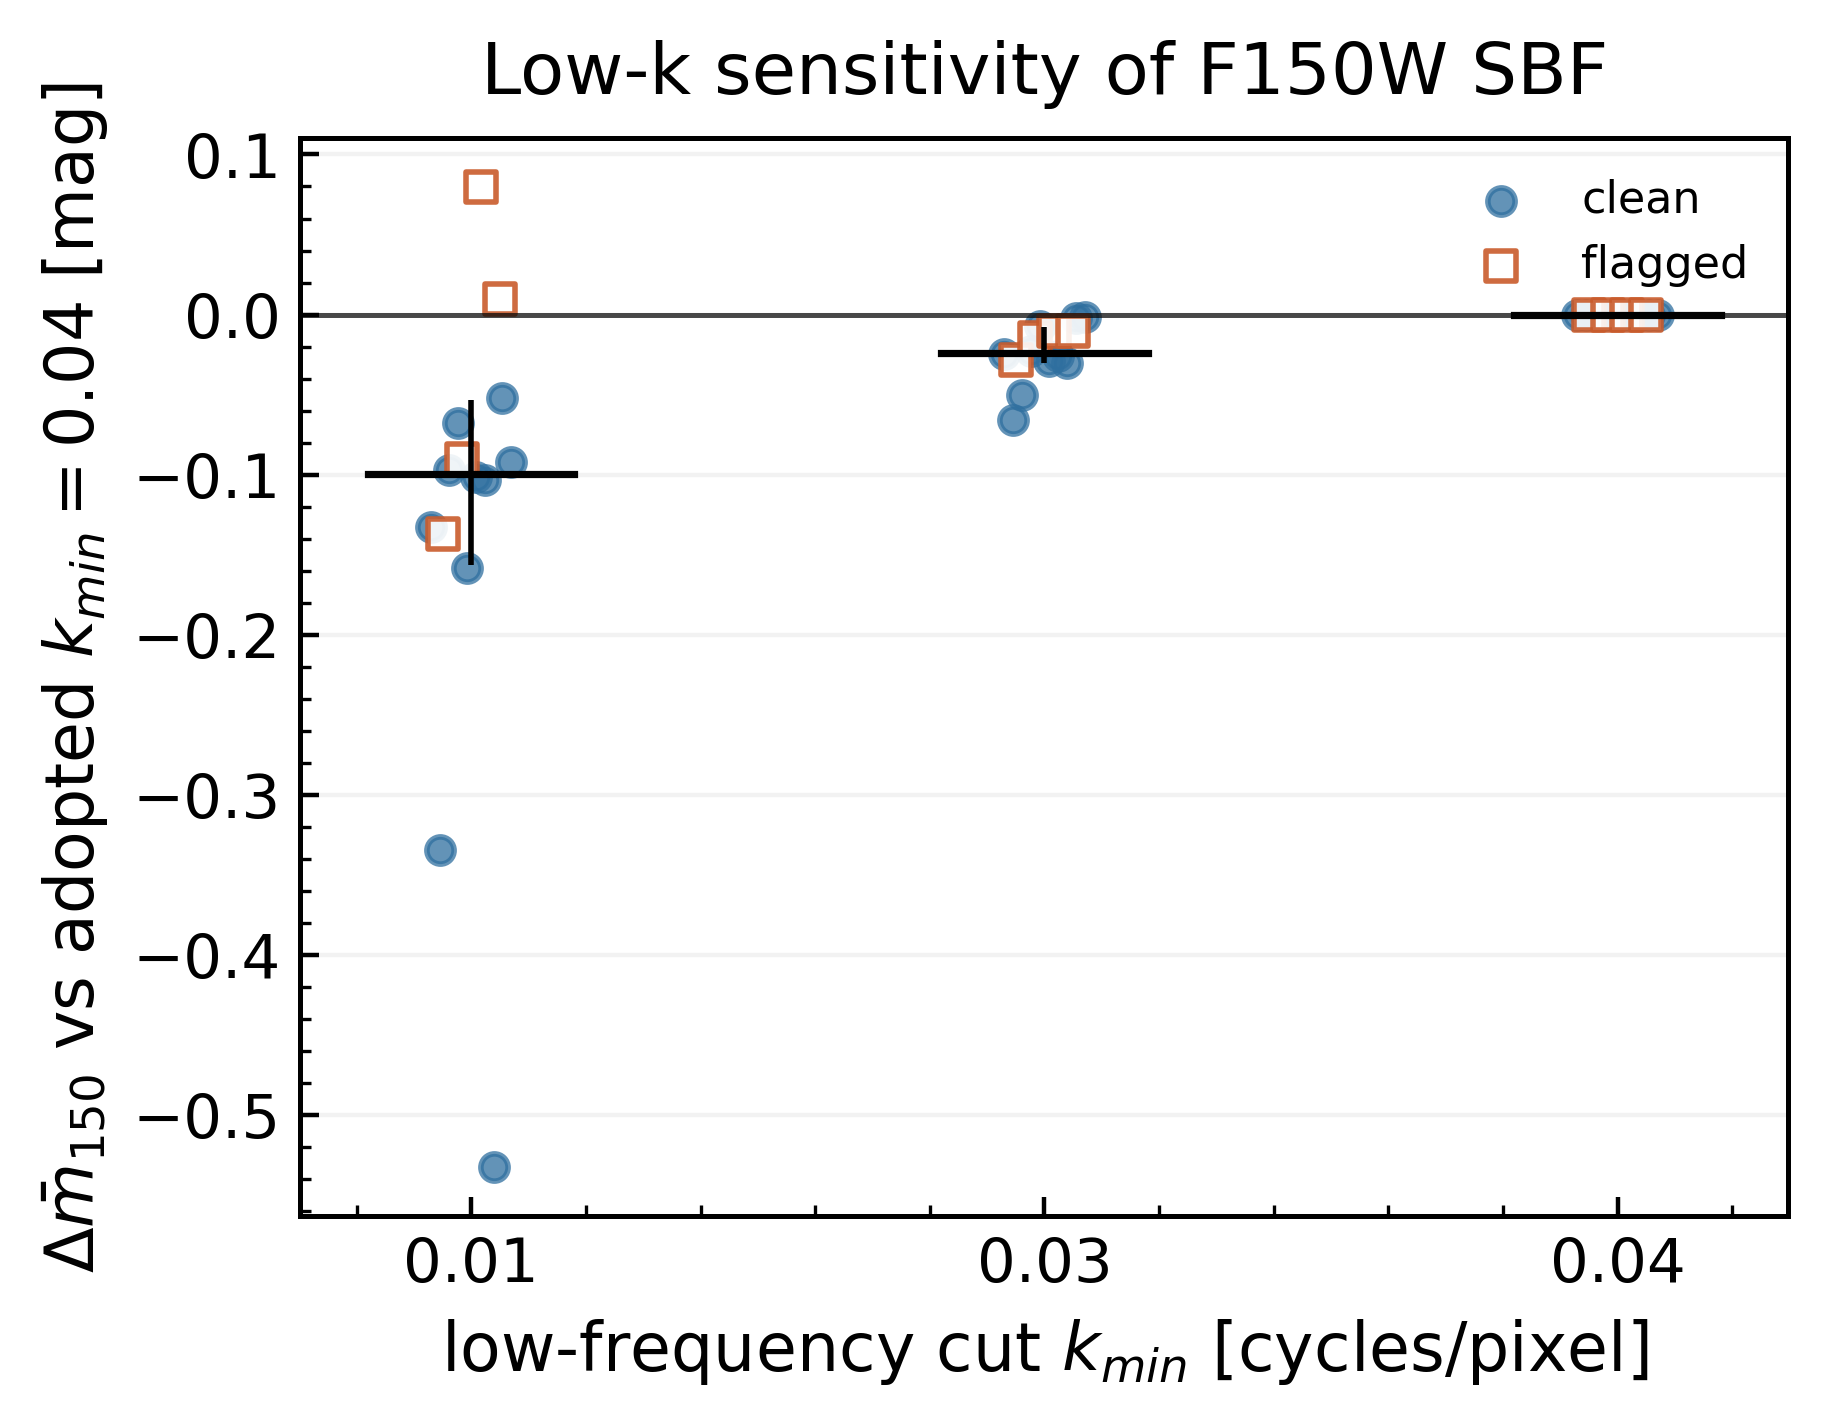

In [24]:
fig, ax = plt.subplots(figsize=(4.8, 3.5))

k_values = sorted(k_summary["kmin"].unique())
for i, kmin in enumerate(k_values):
    sub = k_summary[k_summary["kmin"].eq(kmin)].merge(science_df[["galaxy", "quality_flag"]], on="galaxy", how="left")
    clean_sub = sub[sub["quality_flag"].eq("clean")]
    flagged_sub = sub[~sub["quality_flag"].eq("clean")]

    jitter_clean = np.linspace(-0.07, 0.07, max(len(clean_sub), 1))[:len(clean_sub)]
    jitter_flag = np.linspace(-0.05, 0.05, max(len(flagged_sub), 1))[:len(flagged_sub)]
    ax.scatter(np.full(len(clean_sub), i) + jitter_clean, clean_sub["delta_from_adopted"], s=24, color="#2f6f9f", alpha=0.75, label="clean" if i == 0 else None)
    ax.scatter(np.full(len(flagged_sub), i) + jitter_flag, flagged_sub["delta_from_adopted"], s=30, marker="s", facecolor="white", edgecolor="#c95b2b", alpha=0.9, label="flagged" if i == 0 else None)

    median = np.nanmedian(sub["delta_from_adopted"])
    lo, hi = np.nanpercentile(sub["delta_from_adopted"], [16, 84])
    ax.plot([i - 0.18, i + 0.18], [median, median], color="black", lw=1.3)
    ax.vlines(i, lo, hi, color="black", lw=1.0)

ax.axhline(0, color="black", lw=0.9, alpha=0.7)
ax.set_xticks(range(len(k_values)))
ax.set_xticklabels([f"{k:.2f}" for k in k_values])
ax.set_xlabel(r"low-frequency cut $k_{min}$ [cycles/pixel]")
ax.set_ylabel(r"$\Delta \bar m_{150}$ vs adopted $k_{min}=0.04$ [mag]")
ax.set_title("Low-k sensitivity of F150W SBF", pad=8)
ax.legend(loc="best", fontsize=8)
ax.grid(axis="y", alpha=0.16)
fig.savefig(FIG_DIR / "kmin_sensitivity.pdf")
fig.savefig(FIG_DIR / "kmin_sensitivity.png")
plt.show()


## Абсолютная SBF-калибровка `Mbar_150(color)`

Здесь расстояние уже вычтено: `Mbar_150 = mbar_150 - mu_lit`. Поэтому этот график является основной физической калибровкой, а не просто диагностикой видимых величин.

Фитируем линейную модель

`Mbar_150 = a + b * [(F090W - F150W) - 0.40]`.

Нуль цвета `0.40` выбран только для удобства: тогда `a` — это абсолютная SBF-величина около типичного цвета нашей выборки. Основной фит строится по `clean`-галактикам; flagged-точки показываются на графике, но не задают коэффициенты.


,fit_sample,n_fit,color_pivot,Mbar_at_pivot,sigma_Mbar_at_pivot,slope_mag_per_mag,sigma_slope,chi2_red,weighted_residual_mean,weighted_residual_rms,plain_residual_rms
0,clean,10,0.4,-3.457049,0.014208,1.17651,0.220678,2.15992,-1.548688e-17,0.058513,0.063109


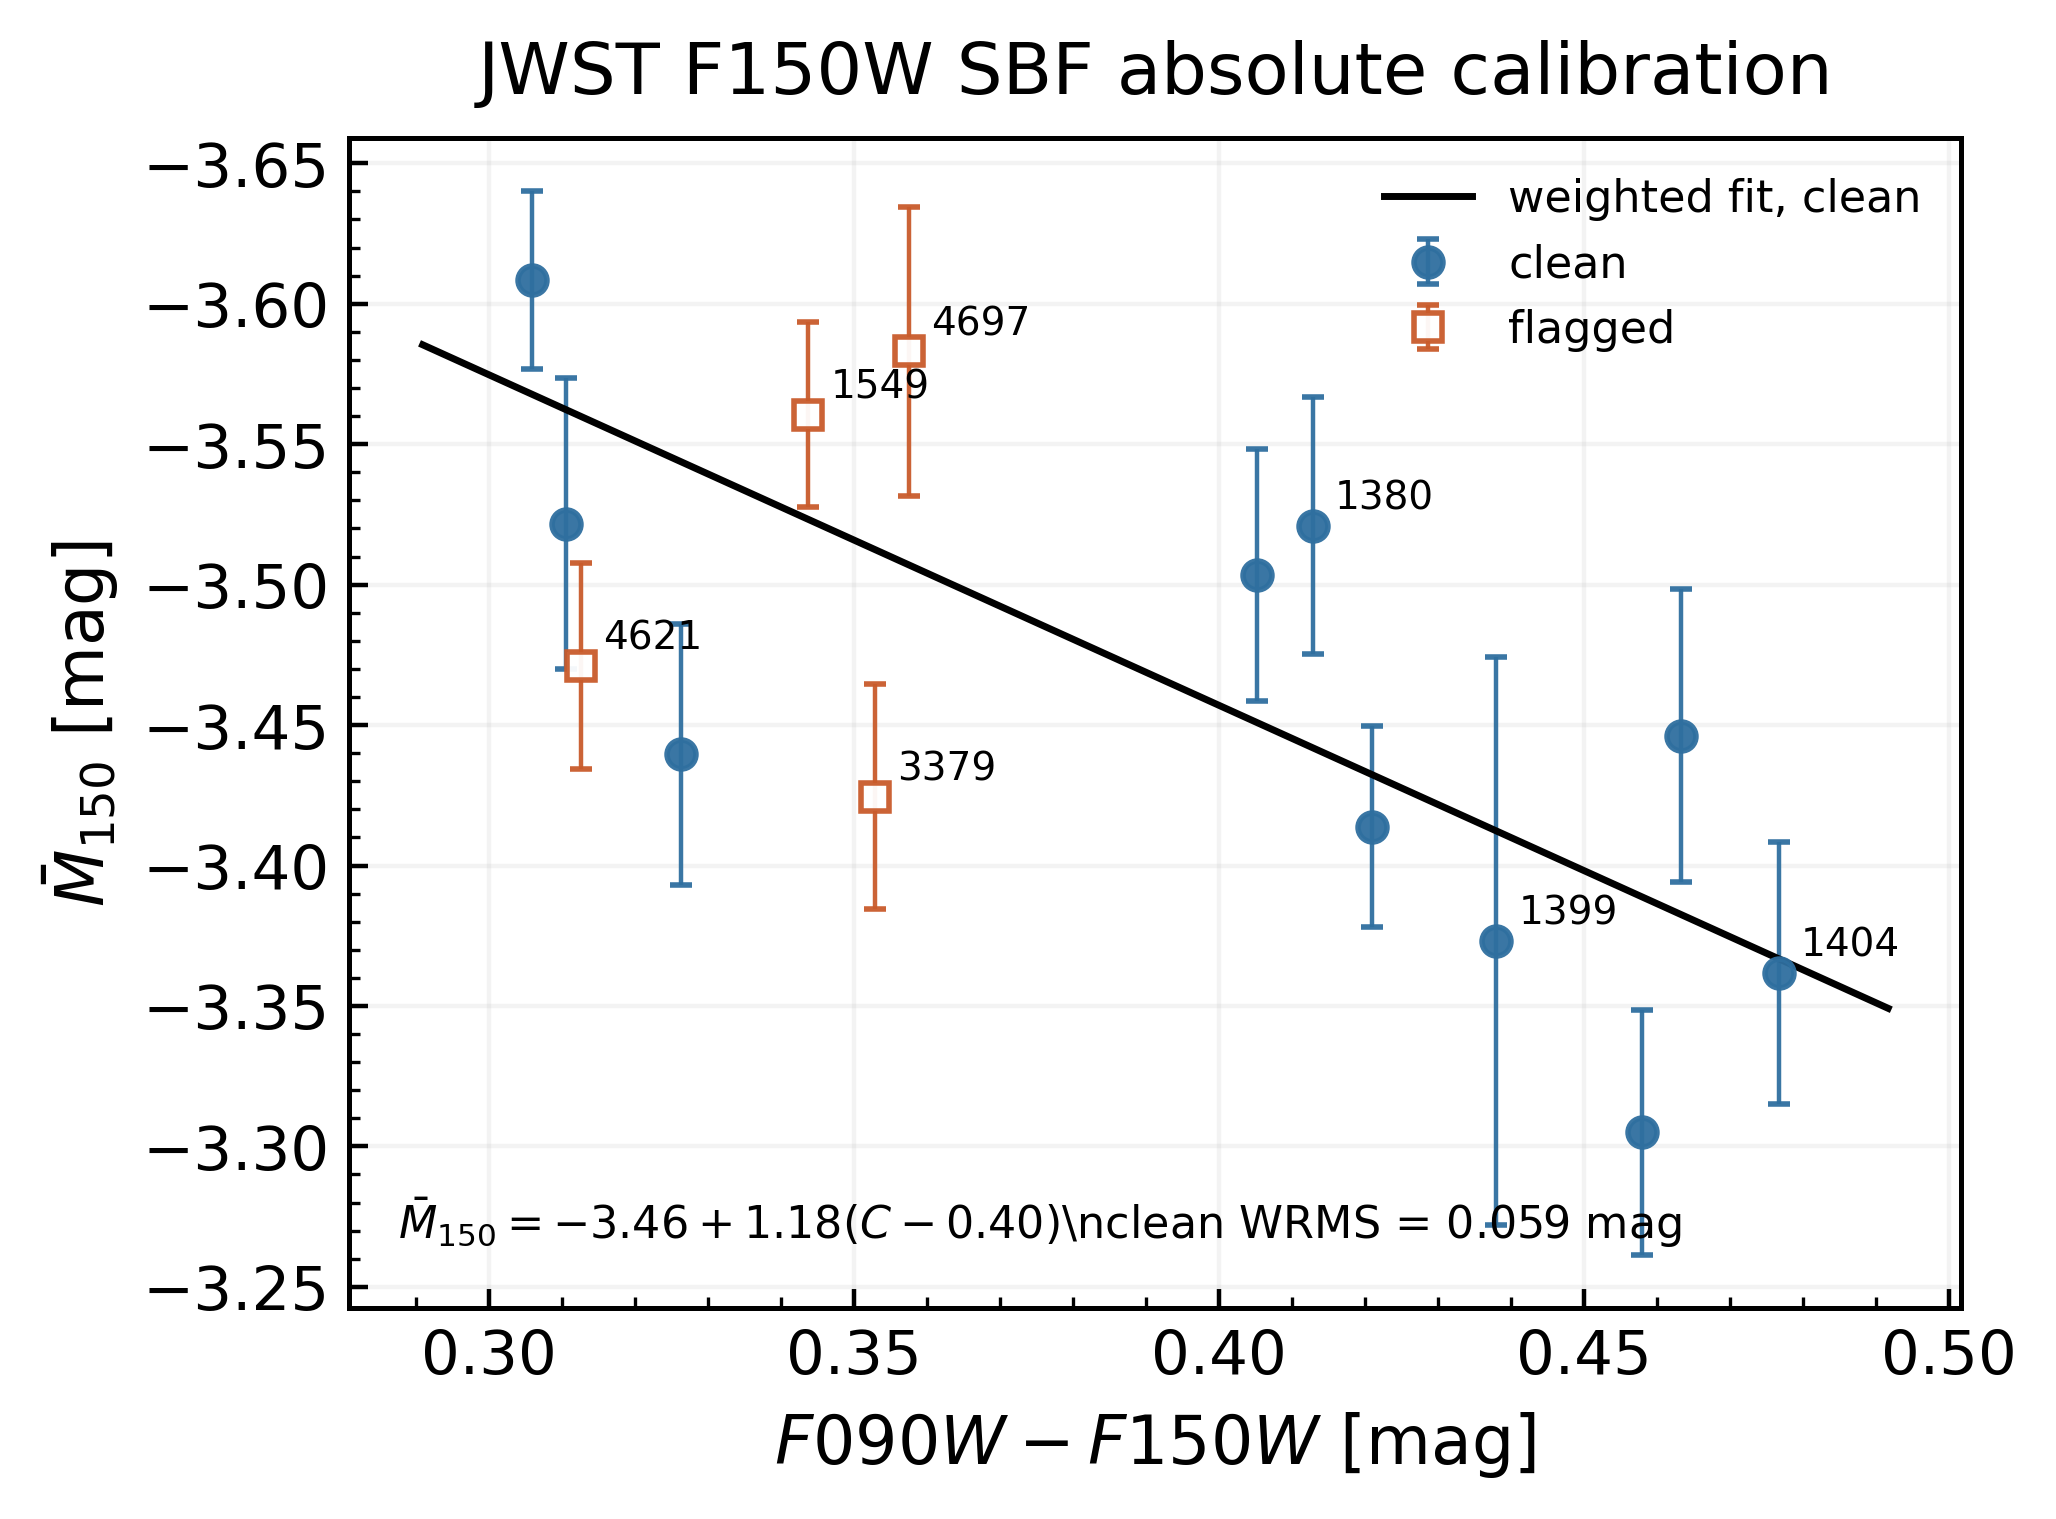

Saved: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/code/sbf2_batch_outputs/paper_absolute_sbf_calibration.csv
Saved: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/code/sbf2_batch_outputs/paper_absolute_sbf_fit_summary.csv


In [26]:
calib = pd.read_csv(CALIBRATION_INPUT_CSV)
calib["has_absolute_sbf"] = np.isfinite(calib["Mbar_150"]) & np.isfinite(calib["sigma_Mbar_150"])
calib["is_clean"] = calib["quality_flag"].eq("clean")

COLOR_PIVOT = 0.40
fit_mask = calib["has_absolute_sbf"] & calib["is_clean"]
plot_mask = calib["has_absolute_sbf"]

if fit_mask.sum() < 3:
    print(f"Need at least 3 clean galaxies with mu_lit; currently have {fit_mask.sum()}.")
    display(calib[["galaxy", "mbar_150", "sigma_mbar_150", "color_F090W_F150W", "mu_lit", "sigma_mu_lit", "distance_source"]])
else:
    def weighted_linear_fit(x, y, sigma, pivot=0.0):
        x0 = np.asarray(x, dtype=float) - pivot
        y = np.asarray(y, dtype=float)
        sigma = np.asarray(sigma, dtype=float)
        X = np.column_stack([np.ones_like(x0), x0])
        w = 1.0 / sigma**2
        xtw = X.T * w
        cov = np.linalg.inv(xtw @ X)
        beta = cov @ (xtw @ y)
        model = X @ beta
        resid = y - model
        dof = max(len(y) - len(beta), 1)
        chi2 = float(np.sum((resid / sigma) ** 2))
        return {
            "intercept": float(beta[0]),
            "slope": float(beta[1]),
            "cov": cov,
            "chi2": chi2,
            "dof": dof,
            "chi2_red": chi2 / dof,
            "resid": resid,
            "model": model,
        }

    fit_df = calib[fit_mask].copy()
    fit = weighted_linear_fit(
        fit_df["color_F090W_F150W"],
        fit_df["Mbar_150"],
        fit_df["sigma_Mbar_150"],
        pivot=COLOR_PIVOT,
    )

    calib["Mbar_150_fit_clean"] = fit["intercept"] + fit["slope"] * (calib["color_F090W_F150W"] - COLOR_PIVOT)
    calib["Mbar_150_residual"] = calib["Mbar_150"] - calib["Mbar_150_fit_clean"]

    x_design = np.column_stack([
        np.ones(len(calib)),
        calib["color_F090W_F150W"].to_numpy(dtype=float) - COLOR_PIVOT,
    ])
    calib["sigma_Mbar_fit"] = np.sqrt(np.einsum("ij,jk,ik->i", x_design, fit["cov"], x_design))

    clean_resid = calib.loc[fit_mask, "Mbar_150_residual"].to_numpy(dtype=float)
    clean_sigma = calib.loc[fit_mask, "sigma_Mbar_150"].to_numpy(dtype=float)
    clean_w = 1.0 / clean_sigma**2
    mean_resid = float(np.average(clean_resid, weights=clean_w))
    wrms_resid = float(np.sqrt(np.average((clean_resid - mean_resid) ** 2, weights=clean_w)))
    rms_resid = float(np.std(clean_resid, ddof=1))

    fit_summary = pd.DataFrame([
        {
            "fit_sample": "clean",
            "n_fit": int(fit_mask.sum()),
            "color_pivot": COLOR_PIVOT,
            "Mbar_at_pivot": fit["intercept"],
            "sigma_Mbar_at_pivot": math.sqrt(fit["cov"][0, 0]),
            "slope_mag_per_mag": fit["slope"],
            "sigma_slope": math.sqrt(fit["cov"][1, 1]),
            "chi2_red": fit["chi2_red"],
            "weighted_residual_mean": mean_resid,
            "weighted_residual_rms": wrms_resid,
            "plain_residual_rms": rms_resid,
        }
    ])
    display(fit_summary)

    fig, ax = plt.subplots(figsize=(5.2, 3.8))
    styles = [
        (calib["is_clean"] & plot_mask, "clean", "o", "#2f6f9f", "#2f6f9f"),
        ((~calib["is_clean"]) & plot_mask, "flagged", "s", "white", "#c95b2b"),
    ]
    for mask, label, marker, mfc, mec in styles:
        sub = calib[mask]
        ax.errorbar(
            sub["color_F090W_F150W"],
            sub["Mbar_150"],
            yerr=sub["sigma_Mbar_150"],
            fmt=marker,
            ms=5.2,
            capsize=2.0,
            lw=0.8,
            color=mec,
            mec=mec,
            mfc=mfc,
            alpha=0.95,
            label=label,
        )

    xgrid = np.linspace(calib.loc[plot_mask, "color_F090W_F150W"].min() - 0.015, calib.loc[plot_mask, "color_F090W_F150W"].max() + 0.015, 200)
    ygrid = fit["intercept"] + fit["slope"] * (xgrid - COLOR_PIVOT)
    ax.plot(xgrid, ygrid, color="black", lw=1.25, label="weighted fit, clean")

    for _, row in calib[plot_mask].iterrows():
        if (row["quality_flag"] != "clean") or row["galaxy"] in {"NGC 1380", "NGC 1399", "NGC 1404"}:
            ax.annotate(row["galaxy"].replace("NGC ", ""), (row["color_F090W_F150W"], row["Mbar_150"]), xytext=(4, 3), textcoords="offset points", fontsize=7)

    ax.invert_yaxis()
    ax.set_xlabel(r"$F090W - F150W$ [mag]")
    ax.set_ylabel(r"$\bar M_{150}$ [mag]")
    ax.set_title("JWST F150W SBF absolute calibration", pad=8)
    ax.text(
        0.03,
        0.05,
        rf"$\bar M_{{150}}={fit['intercept']:.2f}{fit['slope']:+.2f}(C-{COLOR_PIVOT:.2f})$\n"
        rf"clean WRMS = {wrms_resid:.3f} mag",
        transform=ax.transAxes,
        fontsize=8,
        va="bottom",
    )
    ax.legend(loc="best", fontsize=8)
    ax.grid(alpha=0.14)
    fig.savefig(FIG_DIR / "Mbar150_color_calibration.pdf")
    fig.savefig(FIG_DIR / "Mbar150_color_calibration.png")
    plt.show()

    calib.to_csv(BATCH_DIR / "paper_absolute_sbf_calibration.csv", index=False)
    fit_summary.to_csv(BATCH_DIR / "paper_absolute_sbf_fit_summary.csv", index=False)
    print(f"Saved: {BATCH_DIR / 'paper_absolute_sbf_calibration.csv'}")
    print(f"Saved: {BATCH_DIR / 'paper_absolute_sbf_fit_summary.csv'}")


## Проверка расстояний по полученной калибровке

Используем fitted `Mbar_150(color)`, чтобы восстановить модуль расстояния каждой галактики:

`mu_SBF = mbar_150 - Mbar_150(color)`.

Дальше сравниваем `mu_SBF` с литературным `mu_lit`. Это in-sample проверка, потому что те же clean-галактики участвовали в фите; её нельзя продавать как полностью независимую валидацию, но она показывает внутреннюю согласованность пайплайна.


,sample,n,weighted_mean_delta_mu,weighted_rms_delta_mu,plain_rms_delta_mu,median_abs_distance_fraction_percent
0,clean,10,0.000768,0.059398,0.063109,2.133941
1,all,14,0.007202,0.063976,0.066773,2.638304


,galaxy,quality_flag,mu_lit,sigma_mu_lit,mu_sbf_fit,sigma_mu_sbf_fit,mu_residual,sigma_mu_residual,distance_residual_fraction
0,NGC 1380,clean,31.408,0.025,31.328966,0.041036,-0.079034,0.048052,-0.035742
13,NGC 4697,isophote_real_only_failed;sersic_fit_warning,30.324,0.028,30.247902,0.046044,-0.076098,0.053890,-0.034437
8,NGC 4486,clean,31.046,0.025,30.982312,0.050452,-0.063688,0.056307,-0.028904
7,NGC 4472,clean,31.016,0.027,30.963555,0.038713,-0.052445,0.047199,-0.023863
6,NGC 4406,clean,31.096,0.025,31.055227,0.030408,-0.040773,0.039365,-0.018602
3,NGC 1549,truncated_file_warning,31.231,0.026,31.193696,0.026713,-0.037304,0.037277,-0.017033
2,NGC 1404,clean,31.366,0.025,31.371015,0.045803,0.005015,0.052182,0.002312
5,NGC 4374,clean,31.112,0.027,31.130625,0.028171,0.018625,0.039021,0.008614
1,NGC 1399,clean,31.498,0.026,31.537213,0.099123,0.039213,0.102476,0.018222
11,NGC 4636,clean,31.070,0.026,31.110479,0.050066,0.040479,0.056415,0.018816


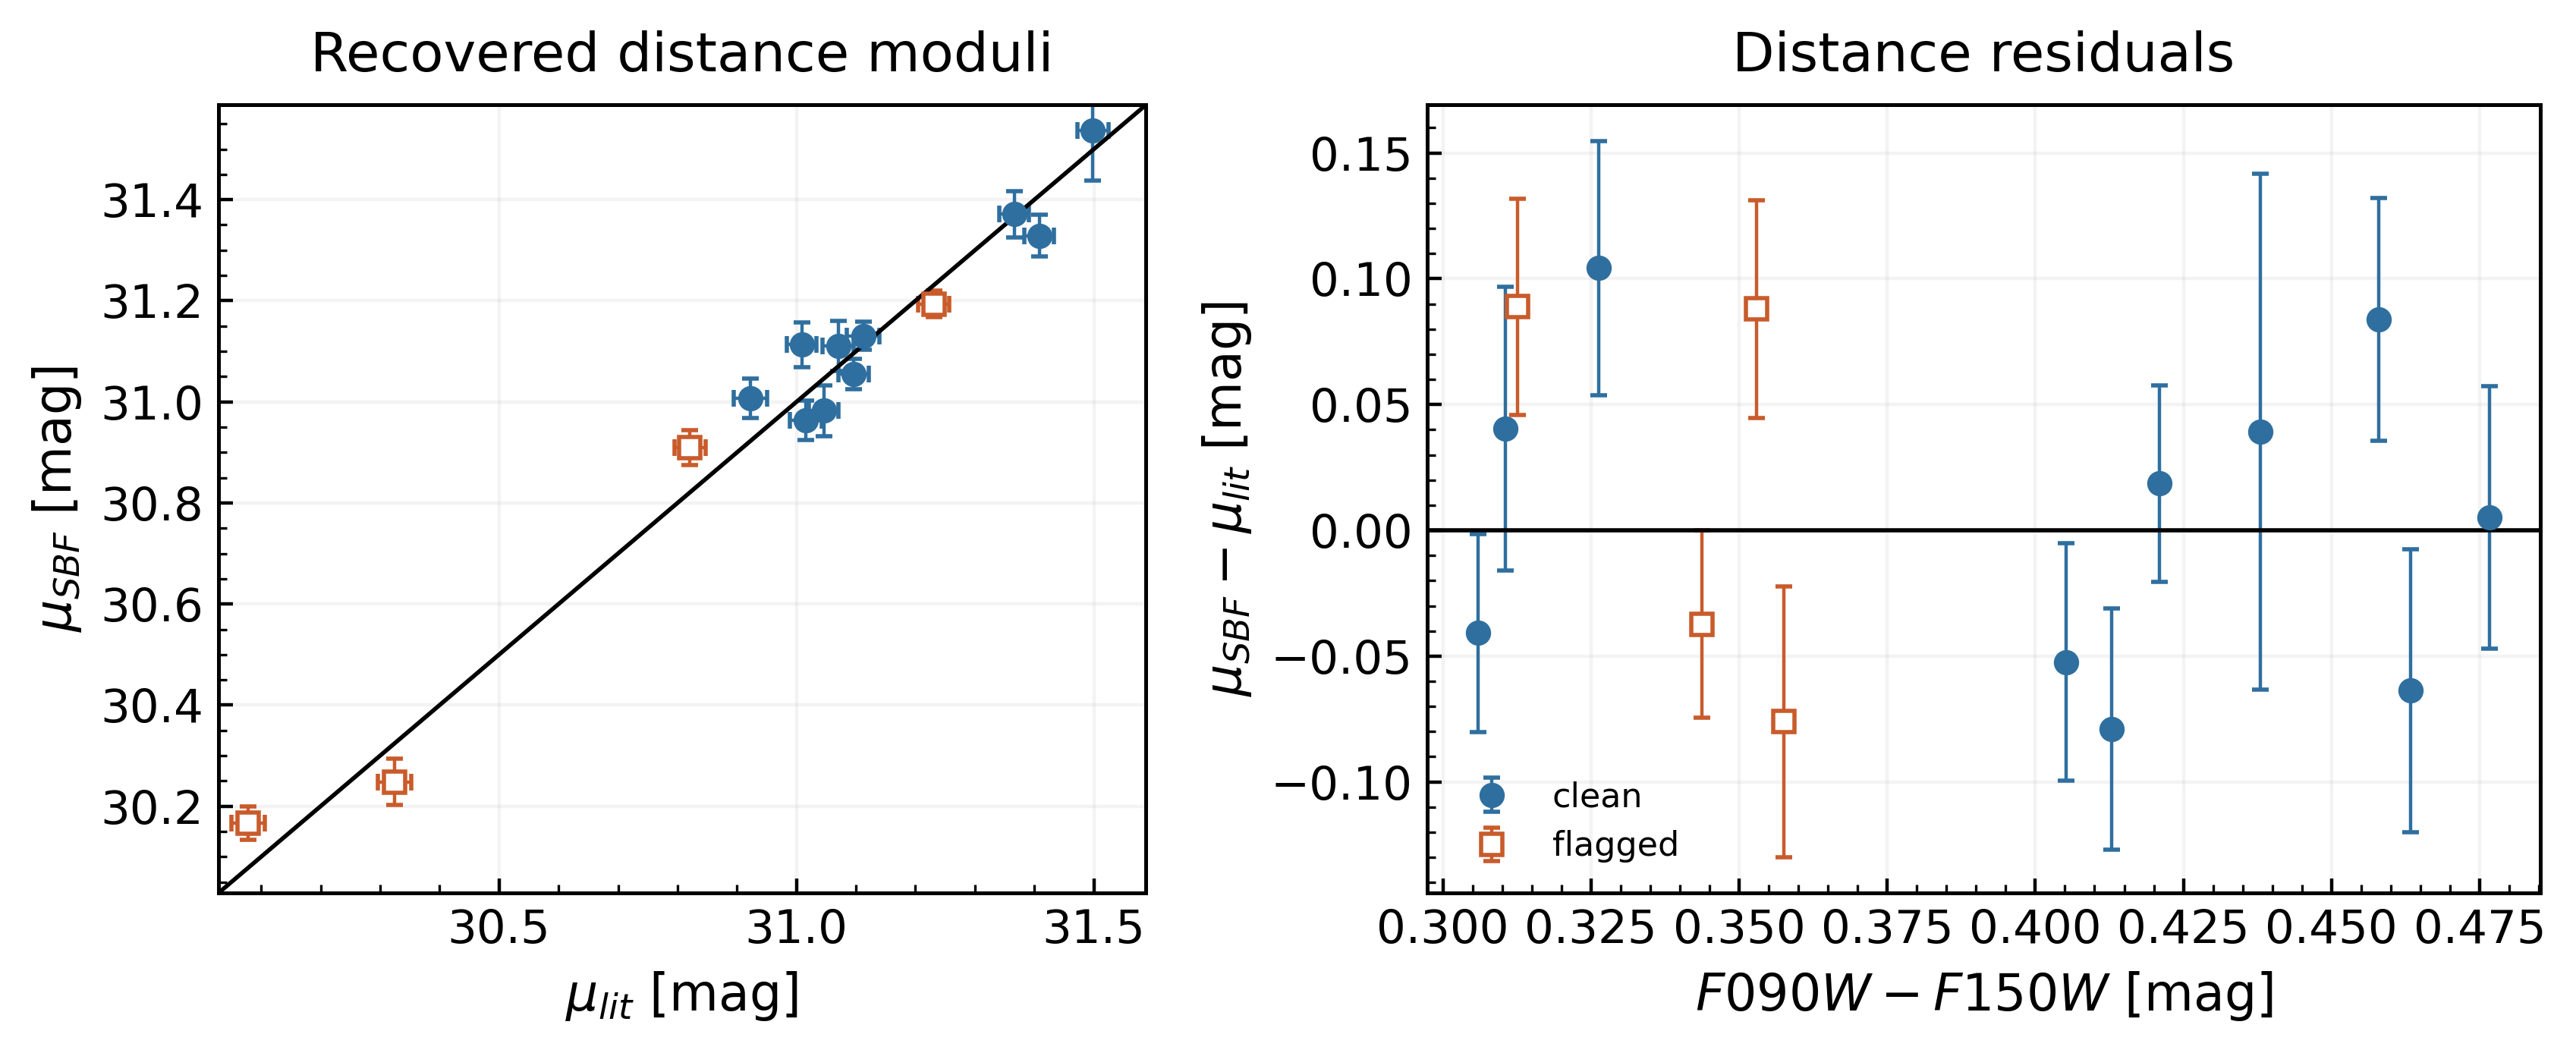

Saved: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/code/sbf2_batch_outputs/paper_sbf_distance_residuals_in_sample.csv


In [27]:
if "Mbar_150_fit_clean" not in calib.columns:
    print("Run the absolute calibration cell first.")
else:
    distance_df = calib[plot_mask].copy()
    distance_df["mu_sbf_fit"] = distance_df["mbar_150"] - distance_df["Mbar_150_fit_clean"]
    distance_df["mu_residual"] = distance_df["mu_sbf_fit"] - distance_df["mu_lit"]
    distance_df["sigma_mu_sbf_fit"] = np.sqrt(distance_df["sigma_mbar_150"]**2 + distance_df["sigma_Mbar_fit"]**2)
    distance_df["sigma_mu_residual"] = np.sqrt(distance_df["sigma_mu_sbf_fit"]**2 + distance_df["sigma_mu_lit"]**2)
    distance_df["distance_residual_fraction"] = 10 ** (distance_df["mu_residual"] / 5.0) - 1.0

    def residual_summary(df, label):
        r = df["mu_residual"].to_numpy(dtype=float)
        s = df["sigma_mu_residual"].to_numpy(dtype=float)
        w = 1.0 / s**2
        mean = float(np.average(r, weights=w))
        wrms = float(np.sqrt(np.average((r - mean) ** 2, weights=w)))
        rms = float(np.std(r, ddof=1)) if len(r) > 1 else np.nan
        return {
            "sample": label,
            "n": len(df),
            "weighted_mean_delta_mu": mean,
            "weighted_rms_delta_mu": wrms,
            "plain_rms_delta_mu": rms,
            "median_abs_distance_fraction_percent": float(np.nanmedian(np.abs(df["distance_residual_fraction"])) * 100),
        }

    distance_summary = pd.DataFrame([
        residual_summary(distance_df[distance_df["is_clean"]], "clean"),
        residual_summary(distance_df, "all"),
    ])
    display(distance_summary)
    display(distance_df[[
        "galaxy",
        "quality_flag",
        "mu_lit",
        "sigma_mu_lit",
        "mu_sbf_fit",
        "sigma_mu_sbf_fit",
        "mu_residual",
        "sigma_mu_residual",
        "distance_residual_fraction",
    ]].sort_values("mu_residual"))

    fig, (ax_mu, ax_res) = plt.subplots(1, 2, figsize=(8.6, 3.6), gridspec_kw={"width_ratios": [1, 1.2]})
    for mask, label, marker, mfc, mec in styles:
        sub = distance_df[mask.loc[distance_df.index]]
        ax_mu.errorbar(sub["mu_lit"], sub["mu_sbf_fit"], xerr=sub["sigma_mu_lit"], yerr=sub["sigma_mu_sbf_fit"], fmt=marker, ms=5.0, capsize=2.0, lw=0.8, color=mec, mec=mec, mfc=mfc, label=label)
        ax_res.errorbar(sub["color_F090W_F150W"], sub["mu_residual"], yerr=sub["sigma_mu_residual"], fmt=marker, ms=5.0, capsize=2.0, lw=0.8, color=mec, mec=mec, mfc=mfc, label=label)

    lim = [min(distance_df["mu_lit"].min(), distance_df["mu_sbf_fit"].min()) - 0.05, max(distance_df["mu_lit"].max(), distance_df["mu_sbf_fit"].max()) + 0.05]
    ax_mu.plot(lim, lim, color="black", lw=1.0)
    ax_mu.set_xlim(lim)
    ax_mu.set_ylim(lim)
    ax_mu.set_xlabel(r"$\mu_{lit}$ [mag]")
    ax_mu.set_ylabel(r"$\mu_{SBF}$ [mag]")
    ax_mu.set_title("Recovered distance moduli", pad=8)
    ax_mu.grid(alpha=0.14)

    ax_res.axhline(0, color="black", lw=1.0)
    ax_res.set_xlabel(r"$F090W - F150W$ [mag]")
    ax_res.set_ylabel(r"$\mu_{SBF} - \mu_{lit}$ [mag]")
    ax_res.set_title("Distance residuals", pad=8)
    ax_res.grid(alpha=0.14)
    ax_res.legend(loc="best", fontsize=8)

    fig.tight_layout()
    fig.savefig(FIG_DIR / "sbf_distance_recovery_in_sample.pdf")
    fig.savefig(FIG_DIR / "sbf_distance_recovery_in_sample.png")
    plt.show()

    distance_df.to_csv(BATCH_DIR / "paper_sbf_distance_residuals_in_sample.csv", index=False)
    distance_summary.to_csv(BATCH_DIR / "paper_sbf_distance_residuals_in_sample_summary.csv", index=False)
    print(f"Saved: {BATCH_DIR / 'paper_sbf_distance_residuals_in_sample.csv'}")


## Leave-one-out проверка расстояний

Чтобы не обманываться in-sample остатками, делаем быстрый leave-one-out тест на clean-выборке: для каждой clean-галактики фит строится по остальным clean-галактикам, затем предсказывается её `Mbar_150(color)` и расстояние.

Это всё ещё не полноценная внешняя проверка на независимой выборке, но уже честнее показывает, насколько калибровка держится при удалении одной точки.


,sample,n,weighted_mean_delta_mu,weighted_rms_delta_mu,plain_rms_delta_mu,median_abs_distance_fraction_percent
0,clean leave-one-out,10,1.632122e-16,0.077183,0.080212,3.055526


,galaxy,color_F090W_F150W,mbar_150,mu_lit,mu_sbf_loo,mu_residual_loo,sigma_mu_residual_loo,Mbar_pred_loo,sigma_Mbar_pred_loo,intercept_loo,slope_loo
4,NGC 4406,0.305918,27.487489,31.096,31.004508,-0.091492,0.047298,-3.517019,0.035216,-3.442205,0.795192
0,NGC 1380,0.412876,27.887067,31.408,31.319614,-0.088386,0.048323,-3.432547,0.015719,-3.448271,1.221111
6,NGC 4486,0.463310,27.599748,31.046,30.969646,-0.076354,0.057098,-3.369898,0.023255,-3.450622,1.275055
5,NGC 4472,0.405187,27.512608,31.016,30.957547,-0.058453,0.047450,-3.444939,0.015212,-3.451143,1.196162
2,NGC 1404,0.476706,28.004212,31.366,31.372735,0.006735,0.053971,-3.368523,0.027272,-3.457777,1.163588
3,NGC 4374,0.420977,27.698256,31.112,31.134944,0.022944,0.039731,-3.436689,0.017238,-3.460824,1.150581
1,NGC 1399,0.437995,28.124865,31.498,31.538420,0.040420,0.102522,-3.413555,0.017719,-3.457913,1.167485
8,NGC 4636,0.310615,27.548268,31.070,31.120156,0.050156,0.057495,-3.571887,0.025254,-3.460127,1.250324
7,NGC 4552,0.457985,27.618028,30.923,31.030171,0.107171,0.049382,-3.412143,0.023032,-3.469777,0.993948
9,NGC 4649,0.326250,27.569380,31.009,31.137205,0.128205,0.051511,-3.567825,0.022291,-3.467180,1.364669


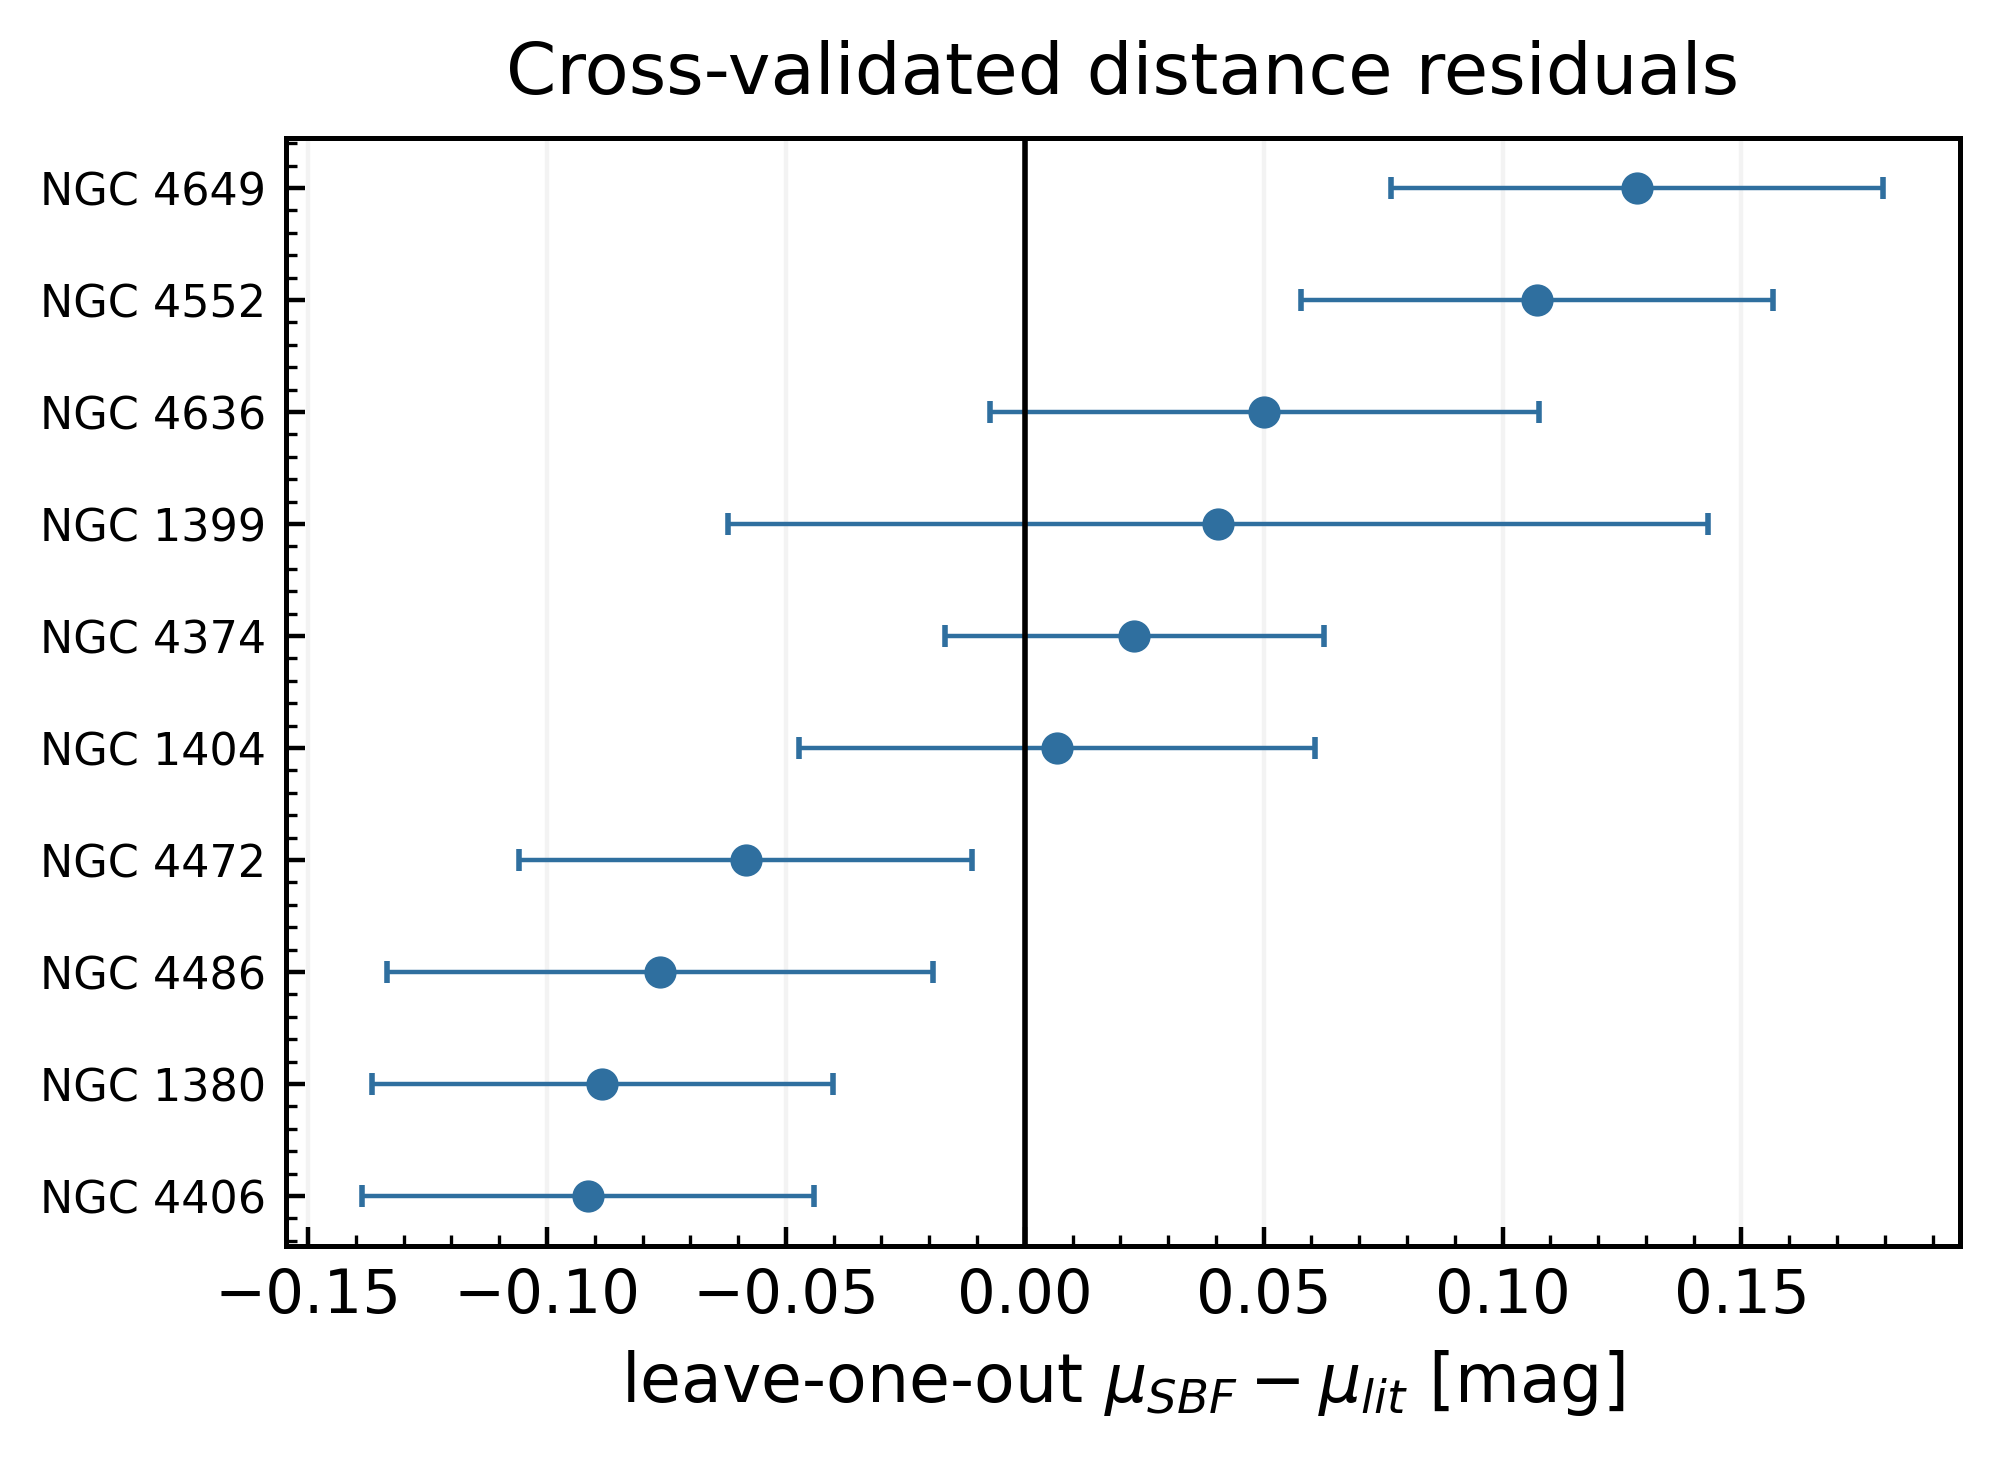

Saved: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/code/sbf2_batch_outputs/paper_sbf_distance_residuals_leave_one_out.csv


In [28]:
if "weighted_linear_fit" not in globals():
    print("Run the absolute calibration cell first.")
else:
    loo_rows = []
    clean_df = calib[plot_mask & calib["is_clean"]].copy().reset_index(drop=True)
    for i, test_row in clean_df.iterrows():
        train = clean_df.drop(index=i)
        if len(train) < 3:
            continue
        loo_fit = weighted_linear_fit(
            train["color_F090W_F150W"],
            train["Mbar_150"],
            train["sigma_Mbar_150"],
            pivot=COLOR_PIVOT,
        )
        color_term = test_row["color_F090W_F150W"] - COLOR_PIVOT
        M_pred = loo_fit["intercept"] + loo_fit["slope"] * color_term
        x_vec = np.array([1.0, color_term])
        sigma_M_pred = float(np.sqrt(x_vec @ loo_fit["cov"] @ x_vec))
        mu_sbf_loo = test_row["mbar_150"] - M_pred
        mu_resid_loo = mu_sbf_loo - test_row["mu_lit"]
        sigma_mu_sbf_loo = math.sqrt(test_row["sigma_mbar_150"]**2 + sigma_M_pred**2)
        sigma_mu_resid_loo = math.sqrt(sigma_mu_sbf_loo**2 + test_row["sigma_mu_lit"]**2)
        loo_rows.append({
            "galaxy": test_row["galaxy"],
            "color_F090W_F150W": test_row["color_F090W_F150W"],
            "mbar_150": test_row["mbar_150"],
            "mu_lit": test_row["mu_lit"],
            "mu_sbf_loo": mu_sbf_loo,
            "mu_residual_loo": mu_resid_loo,
            "sigma_mu_residual_loo": sigma_mu_resid_loo,
            "Mbar_pred_loo": M_pred,
            "sigma_Mbar_pred_loo": sigma_M_pred,
            "intercept_loo": loo_fit["intercept"],
            "slope_loo": loo_fit["slope"],
        })

    loo_df = pd.DataFrame(loo_rows)
    if loo_df.empty:
        print("No leave-one-out rows produced.")
    else:
        r = loo_df["mu_residual_loo"].to_numpy(dtype=float)
        s = loo_df["sigma_mu_residual_loo"].to_numpy(dtype=float)
        w = 1.0 / s**2
        loo_mean = float(np.average(r, weights=w))
        loo_wrms = float(np.sqrt(np.average((r - loo_mean) ** 2, weights=w)))
        loo_rms = float(np.std(r, ddof=1))
        loo_summary = pd.DataFrame([
            {
                "sample": "clean leave-one-out",
                "n": len(loo_df),
                "weighted_mean_delta_mu": loo_mean,
                "weighted_rms_delta_mu": loo_wrms,
                "plain_rms_delta_mu": loo_rms,
                "median_abs_distance_fraction_percent": float(np.nanmedian(np.abs(10 ** (loo_df["mu_residual_loo"] / 5.0) - 1.0)) * 100),
            }
        ])
        display(loo_summary)
        display(loo_df.sort_values("mu_residual_loo"))

        fig, ax = plt.subplots(figsize=(5.4, 3.6))
        order = loo_df.sort_values("mu_residual_loo").reset_index(drop=True)
        y = np.arange(len(order))
        ax.errorbar(order["mu_residual_loo"], y, xerr=order["sigma_mu_residual_loo"], fmt="o", ms=4.8, capsize=2.0, color="#2f6f9f", lw=0.8)
        ax.axvline(0, color="black", lw=1.0)
        ax.set_yticks(y)
        ax.set_yticklabels(order["galaxy"], fontsize=8)
        ax.set_xlabel(r"leave-one-out $\mu_{SBF} - \mu_{lit}$ [mag]")
        ax.set_title("Cross-validated distance residuals", pad=8)
        ax.grid(axis="x", alpha=0.14)
        fig.savefig(FIG_DIR / "sbf_distance_recovery_leave_one_out.pdf")
        fig.savefig(FIG_DIR / "sbf_distance_recovery_leave_one_out.png")
        plt.show()

        loo_df.to_csv(BATCH_DIR / "paper_sbf_distance_residuals_leave_one_out.csv", index=False)
        loo_summary.to_csv(BATCH_DIR / "paper_sbf_distance_residuals_leave_one_out_summary.csv", index=False)
        print(f"Saved: {BATCH_DIR / 'paper_sbf_distance_residuals_leave_one_out.csv'}")


## Paper-ready главные графики

Эта ячейка строит три основные фигуры для текста: абсолютную калибровку `Mbar_150(color)`, сравнение восстановленных расстояний `mu_SBF` с литературными `mu_lit` и leave-one-out остатки. Старые диагностические графики выше оставлены без удаления.

Отличия от диагностических версий:

- исправлена подпись fit без буквального `\\n`;
- добавлена серая полоса внутреннего разброса `sigma_int`, рассчитанного так, чтобы `chi2_red` clean-fit стал равен 1;
- clean/flagged точки оформлены единообразно и менее агрессивно;
- итоговые файлы сохраняются с префиксом `paper_main_*` в `paper_figures/`.


,fit_sample,n_fit,color_pivot,Mbar_at_pivot,sigma_Mbar_at_pivot,slope_mag_per_mag,sigma_slope,chi2_red_formal,sigma_int_for_chi2red_1,Mbar_at_pivot_with_sigma_int_weights,slope_with_sigma_int_weights,weighted_residual_rms
0,clean,10,0.4,-3.457049,0.014208,1.17651,0.220678,2.15992,0.047548,-3.454786,1.073554,0.058513


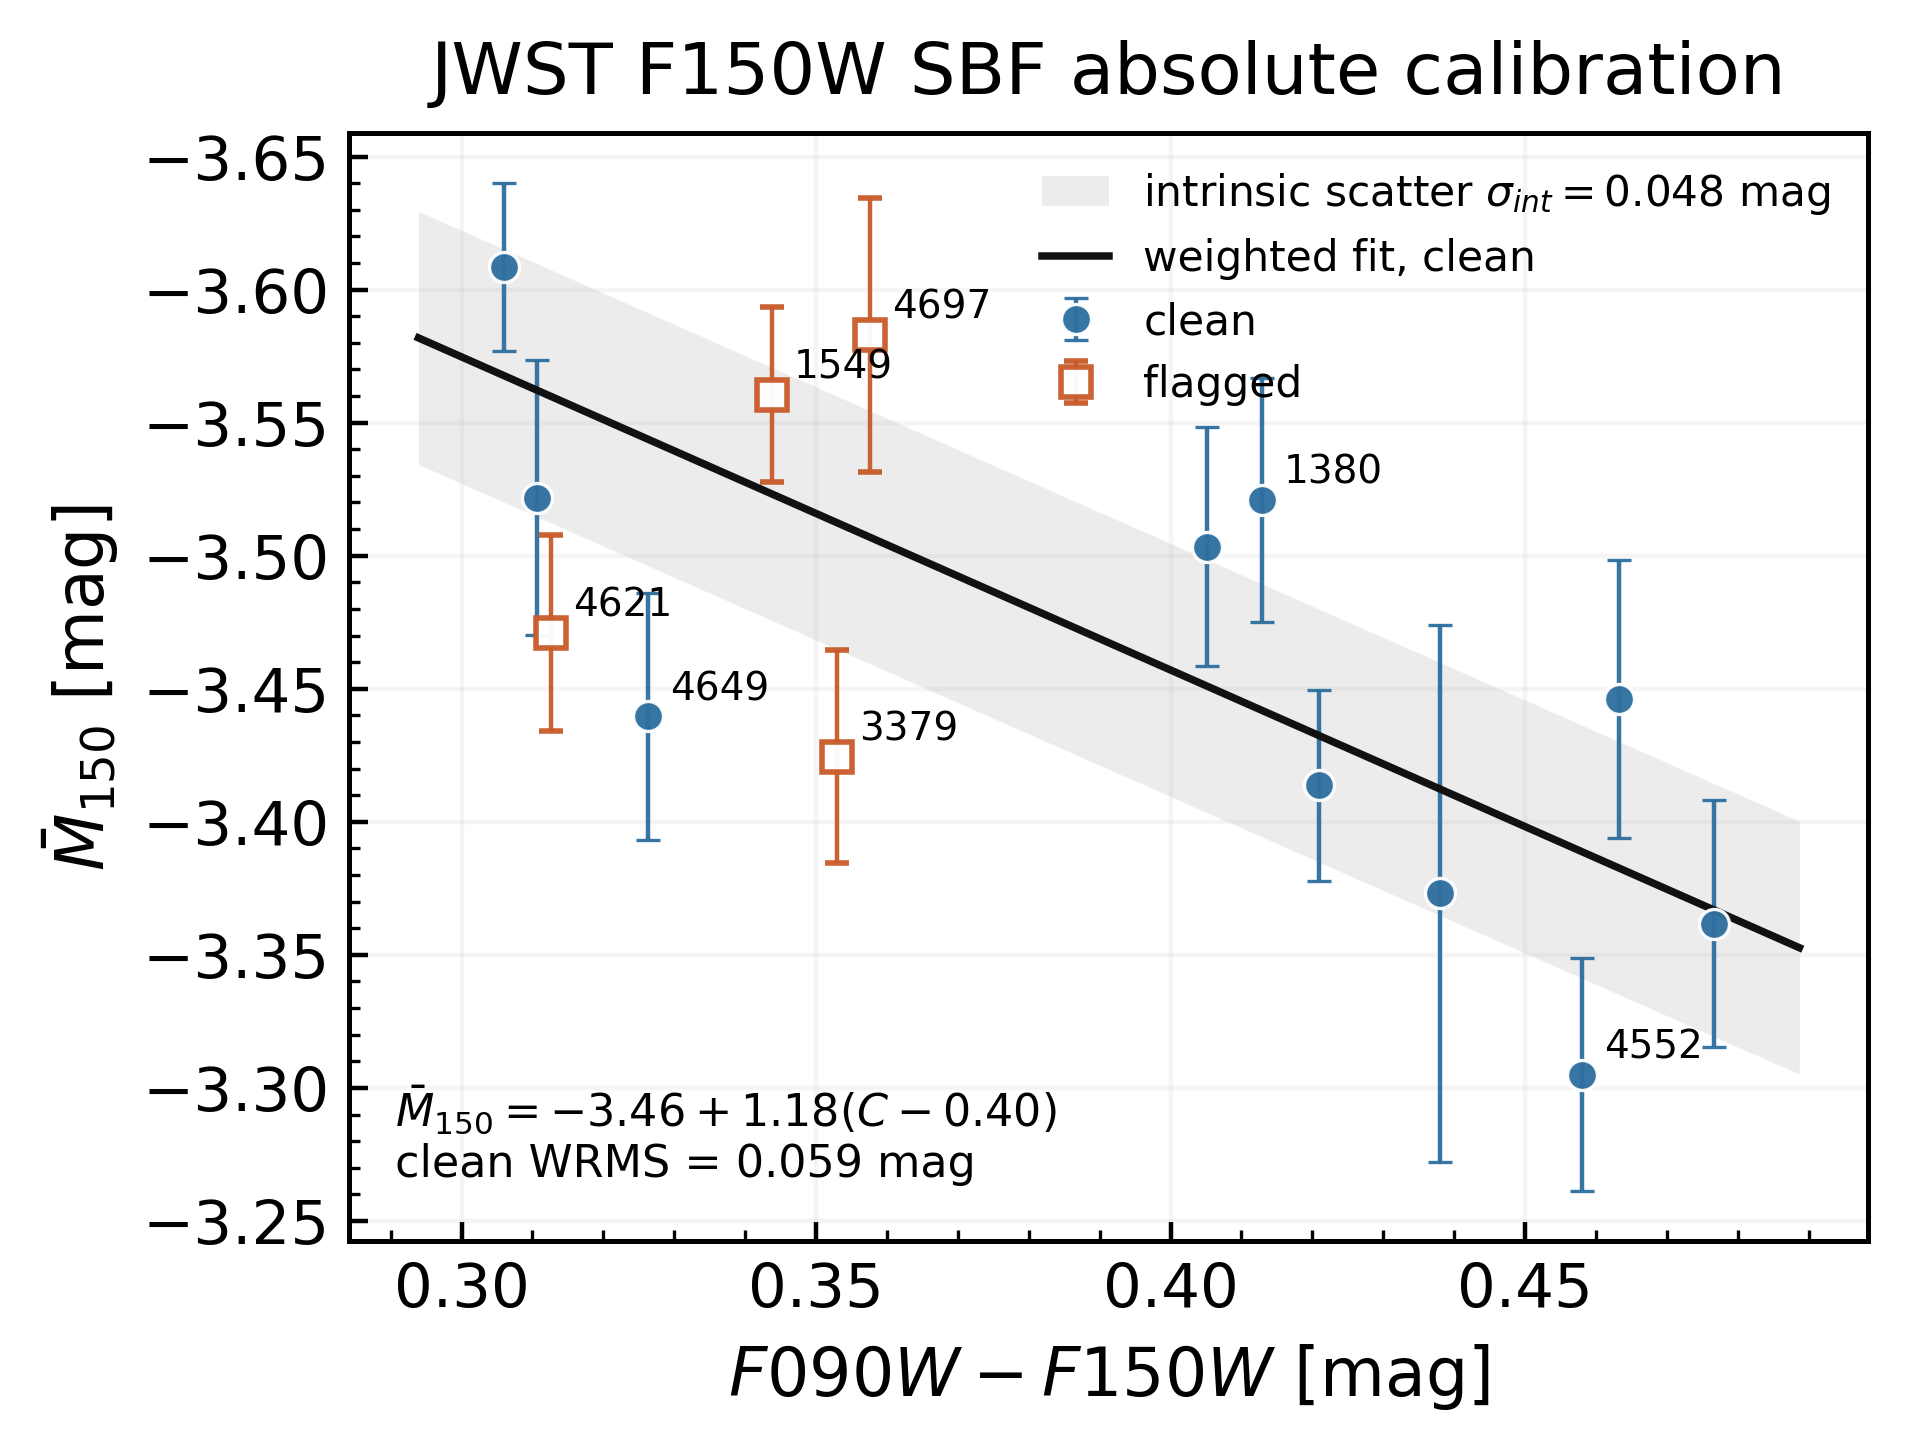

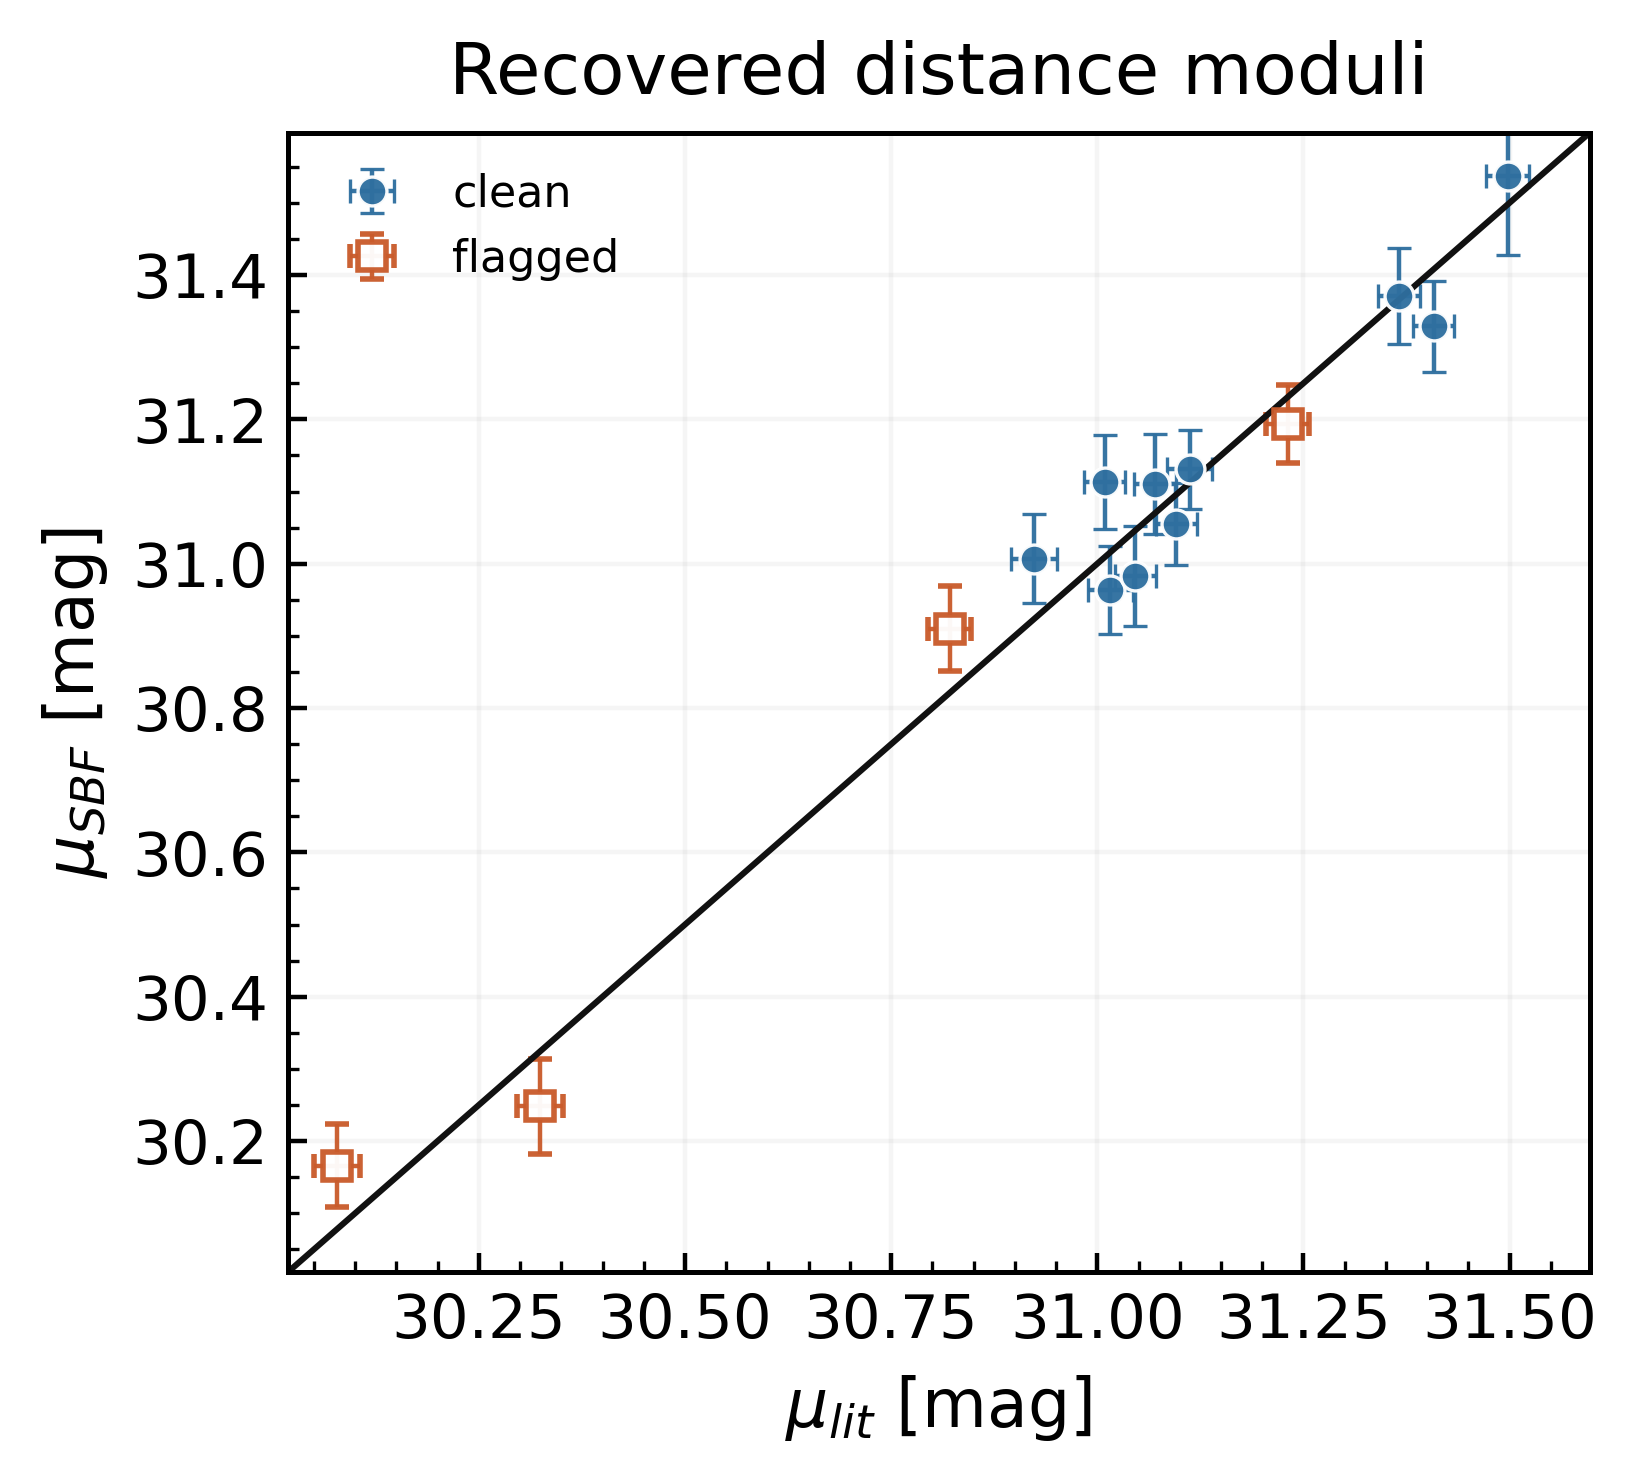

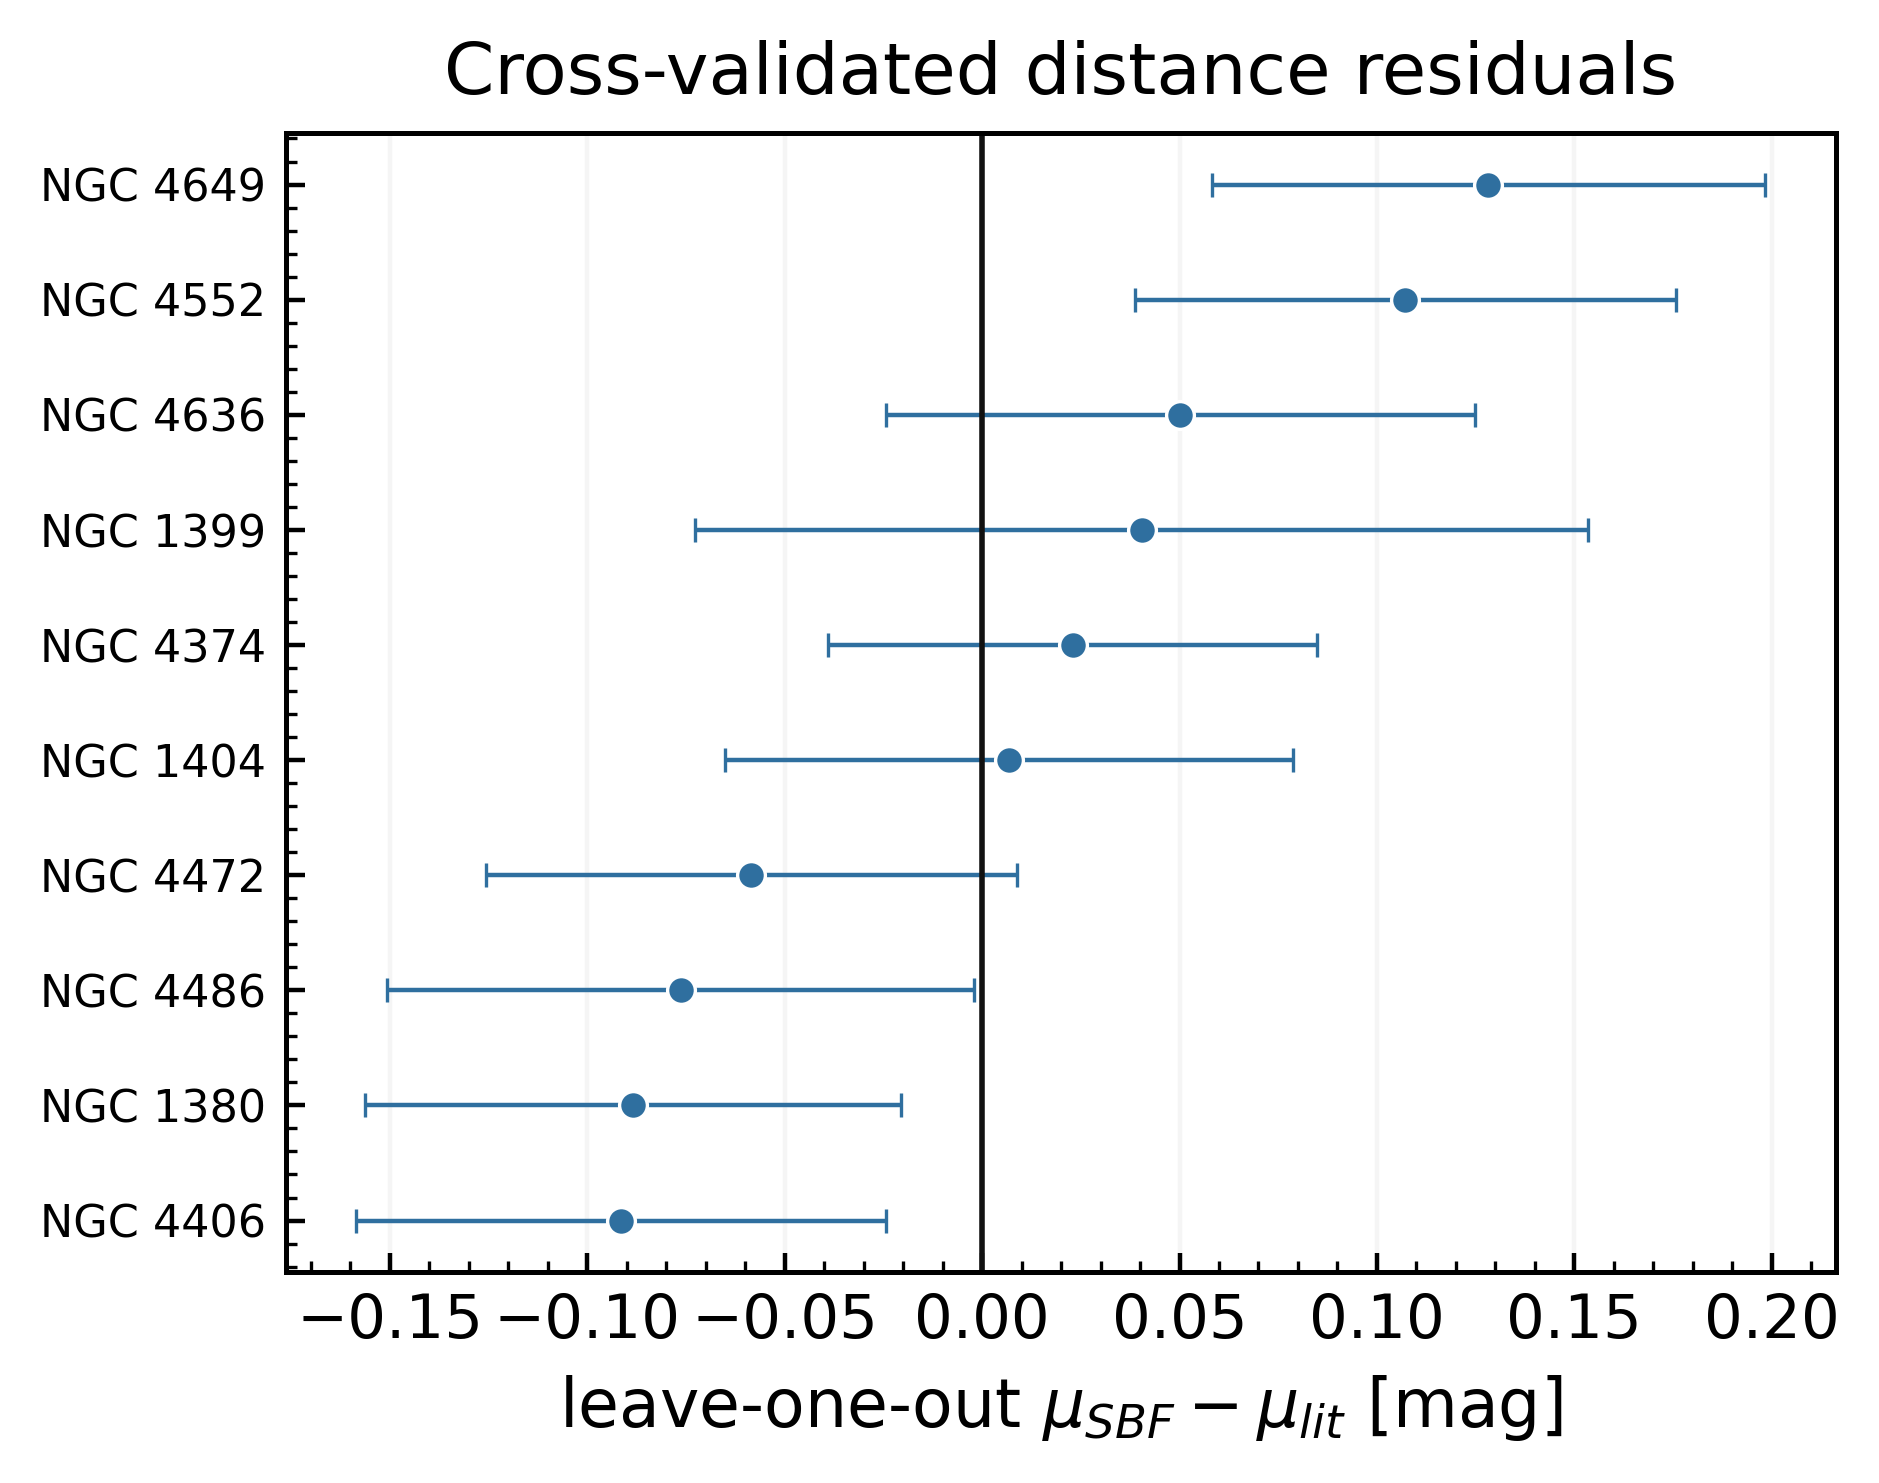

Saved: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/code/sbf2_batch_outputs/paper_absolute_sbf_calibration.csv
Saved: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/code/sbf2_batch_outputs/paper_main_absolute_sbf_fit_summary.csv
Saved: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/code/sbf2_batch_outputs/paper_main_sbf_distance_residuals.csv
Saved: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/code/sbf2_batch_outputs/paper_main_sbf_distance_residuals_leave_one_out.csv


In [29]:
PAPER_STYLE = {
    "clean": {"color": "#2f6f9f", "marker": "o", "mfc": "#2f6f9f", "mec": "white", "mew": 0.6},
    "flagged": {"color": "#c95b2b", "marker": "s", "mfc": "white", "mec": "#c95b2b", "mew": 1.0},
    "fit": "#111111",
    "band": "#9a9a9a",
}

PAPER_COLOR_PIVOT = 0.40
PAPER_ABS_CSV = BATCH_DIR / "paper_absolute_sbf_calibration.csv"
PAPER_FIT_SUMMARY_CSV = BATCH_DIR / "paper_main_absolute_sbf_fit_summary.csv"
PAPER_DISTANCE_CSV = BATCH_DIR / "paper_main_sbf_distance_residuals.csv"
PAPER_LOO_CSV = BATCH_DIR / "paper_main_sbf_distance_residuals_leave_one_out.csv"

paper_calib = pd.read_csv(CALIBRATION_INPUT_CSV).copy()
paper_calib["has_absolute_sbf"] = np.isfinite(paper_calib["Mbar_150"]) & np.isfinite(paper_calib["sigma_Mbar_150"])
paper_calib["is_clean"] = paper_calib["quality_flag"].eq("clean")
paper_fit_mask = paper_calib["has_absolute_sbf"] & paper_calib["is_clean"]
paper_plot_mask = paper_calib["has_absolute_sbf"]

def paper_weighted_linear_fit(x, y, sigma, pivot=PAPER_COLOR_PIVOT):
    x0 = np.asarray(x, dtype=float) - pivot
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    X = np.column_stack([np.ones_like(x0), x0])
    w = 1.0 / sigma**2
    xtw = X.T * w
    cov = np.linalg.inv(xtw @ X)
    beta = cov @ (xtw @ y)
    model = X @ beta
    resid = y - model
    dof = max(len(y) - len(beta), 1)
    chi2 = float(np.sum((resid / sigma) ** 2))
    return {
        "intercept": float(beta[0]),
        "slope": float(beta[1]),
        "cov": cov,
        "model": model,
        "resid": resid,
        "chi2": chi2,
        "dof": dof,
        "chi2_red": chi2 / dof,
    }

def paper_predict_linear(fit, color, pivot=PAPER_COLOR_PIVOT):
    color = np.asarray(color, dtype=float)
    X = np.column_stack([np.ones_like(color), color - pivot])
    y = X @ np.array([fit["intercept"], fit["slope"]])
    sigma = np.sqrt(np.einsum("ij,jk,ik->i", X, fit["cov"], X))
    return y, sigma

def paper_chi2red_with_intrinsic(clean_df, sigma_int):
    sigma_eff = np.sqrt(clean_df["sigma_Mbar_150"].to_numpy(dtype=float)**2 + sigma_int**2)
    fit = paper_weighted_linear_fit(clean_df["color_F090W_F150W"], clean_df["Mbar_150"], sigma_eff)
    return fit["chi2_red"], fit

def paper_find_sigma_int(clean_df):
    chi0, _ = paper_chi2red_with_intrinsic(clean_df, 0.0)
    if chi0 <= 1.0:
        return 0.0
    lo, hi = 0.0, 0.02
    while paper_chi2red_with_intrinsic(clean_df, hi)[0] > 1.0:
        hi *= 2.0
        if hi > 1.0:
            raise RuntimeError("Could not bracket sigma_int")
    for _ in range(64):
        mid = 0.5 * (lo + hi)
        if paper_chi2red_with_intrinsic(clean_df, mid)[0] > 1.0:
            lo = mid
        else:
            hi = mid
    return hi

clean_fit_df = paper_calib[paper_fit_mask].copy()
paper_formal_fit = paper_weighted_linear_fit(
    clean_fit_df["color_F090W_F150W"],
    clean_fit_df["Mbar_150"],
    clean_fit_df["sigma_Mbar_150"],
)
paper_sigma_int = paper_find_sigma_int(clean_fit_df)
paper_intrinsic_chi2, paper_intrinsic_fit = paper_chi2red_with_intrinsic(clean_fit_df, paper_sigma_int)

paper_calib["Mbar_150_fit_paper"], paper_calib["sigma_Mbar_fit_paper"] = paper_predict_linear(
    paper_formal_fit,
    paper_calib["color_F090W_F150W"],
)
paper_calib["Mbar_150_residual_paper"] = paper_calib["Mbar_150"] - paper_calib["Mbar_150_fit_paper"]
paper_calib["mu_sbf_paper"] = paper_calib["mbar_150"] - paper_calib["Mbar_150_fit_paper"]
paper_calib["mu_residual_paper"] = paper_calib["mu_sbf_paper"] - paper_calib["mu_lit"]
paper_calib["sigma_mu_sbf_paper"] = np.sqrt(
    paper_calib["sigma_mbar_150"]**2 + paper_calib["sigma_Mbar_fit_paper"]**2 + paper_sigma_int**2
)
paper_calib["sigma_mu_residual_paper"] = np.sqrt(
    paper_calib["sigma_mu_sbf_paper"]**2 + paper_calib["sigma_mu_lit"]**2
)

paper_clean_resid = paper_calib.loc[paper_fit_mask, "Mbar_150_residual_paper"].to_numpy(dtype=float)
paper_clean_sigma = paper_calib.loc[paper_fit_mask, "sigma_Mbar_150"].to_numpy(dtype=float)
paper_clean_w = 1.0 / paper_clean_sigma**2
paper_clean_mean = float(np.average(paper_clean_resid, weights=paper_clean_w))
paper_clean_wrms = float(np.sqrt(np.average((paper_clean_resid - paper_clean_mean) ** 2, weights=paper_clean_w)))

paper_fit_summary = pd.DataFrame([
    {
        "fit_sample": "clean",
        "n_fit": int(paper_fit_mask.sum()),
        "color_pivot": PAPER_COLOR_PIVOT,
        "Mbar_at_pivot": paper_formal_fit["intercept"],
        "sigma_Mbar_at_pivot": math.sqrt(paper_formal_fit["cov"][0, 0]),
        "slope_mag_per_mag": paper_formal_fit["slope"],
        "sigma_slope": math.sqrt(paper_formal_fit["cov"][1, 1]),
        "chi2_red_formal": paper_formal_fit["chi2_red"],
        "sigma_int_for_chi2red_1": paper_sigma_int,
        "Mbar_at_pivot_with_sigma_int_weights": paper_intrinsic_fit["intercept"],
        "slope_with_sigma_int_weights": paper_intrinsic_fit["slope"],
        "weighted_residual_rms": paper_clean_wrms,
    }
])
display(paper_fit_summary)

# Figure 1: absolute calibration.
fig, ax = plt.subplots(figsize=(4.9, 3.6))
for is_clean, label in [(True, "clean"), (False, "flagged")]:
    sub = paper_calib[paper_plot_mask & paper_calib["is_clean"].eq(is_clean)]
    st = PAPER_STYLE[label]
    ax.errorbar(
        sub["color_F090W_F150W"],
        sub["Mbar_150"],
        yerr=sub["sigma_Mbar_150"],
        fmt=st["marker"],
        ms=5.4,
        capsize=2.2,
        lw=0.8,
        color=st["color"],
        mec=st["mec"],
        mfc=st["mfc"],
        mew=st["mew"],
        alpha=0.96,
        label=label,
    )

xgrid = np.linspace(
    paper_calib.loc[paper_plot_mask, "color_F090W_F150W"].min() - 0.012,
    paper_calib.loc[paper_plot_mask, "color_F090W_F150W"].max() + 0.012,
    300,
)
ygrid = paper_formal_fit["intercept"] + paper_formal_fit["slope"] * (xgrid - PAPER_COLOR_PIVOT)
ax.fill_between(
    xgrid,
    ygrid - paper_sigma_int,
    ygrid + paper_sigma_int,
    color=PAPER_STYLE["band"],
    alpha=0.18,
    lw=0,
    label=rf"intrinsic scatter $\sigma_{{int}}={paper_sigma_int:.3f}$ mag",
)
ax.plot(xgrid, ygrid, color=PAPER_STYLE["fit"], lw=1.35, label="weighted fit, clean")

label_mask = (~paper_calib["is_clean"]) | (paper_calib["Mbar_150_residual_paper"].abs() >= 0.075)
for _, row in paper_calib[paper_plot_mask & label_mask].iterrows():
    ax.annotate(row["galaxy"].replace("NGC ", ""), (row["color_F090W_F150W"], row["Mbar_150"]), xytext=(4, 3), textcoords="offset points", fontsize=7)

fit_text = (
    rf"$\bar M_{{150}}={paper_formal_fit['intercept']:.2f}"
    rf"{paper_formal_fit['slope']:+.2f}(C-{PAPER_COLOR_PIVOT:.2f})$" "\n"
    rf"clean WRMS = {paper_clean_wrms:.3f} mag"
)
ax.text(0.03, 0.05, fit_text, transform=ax.transAxes, fontsize=8, va="bottom")
ax.invert_yaxis()
ax.set_xlabel(r"$F090W - F150W$ [mag]")
ax.set_ylabel(r"$\bar M_{150}$ [mag]")
ax.set_title("JWST F150W SBF absolute calibration", pad=7)
ax.legend(loc="best", fontsize=7.6, handlelength=1.6)
ax.grid(alpha=0.12)
fig.savefig(FIG_DIR / "paper_main_Mbar150_color_calibration.pdf")
fig.savefig(FIG_DIR / "paper_main_Mbar150_color_calibration.png")
plt.show()

# Figure 2: recovered distance moduli.
fig, ax = plt.subplots(figsize=(4.2, 3.7))
for is_clean, label in [(True, "clean"), (False, "flagged")]:
    sub = paper_calib[paper_plot_mask & paper_calib["is_clean"].eq(is_clean)]
    st = PAPER_STYLE[label]
    ax.errorbar(
        sub["mu_lit"],
        sub["mu_sbf_paper"],
        xerr=sub["sigma_mu_lit"],
        yerr=sub["sigma_mu_sbf_paper"],
        fmt=st["marker"],
        ms=5.2,
        capsize=2.1,
        lw=0.8,
        color=st["color"],
        mec=st["mec"],
        mfc=st["mfc"],
        mew=st["mew"],
        alpha=0.96,
        label=label,
    )
lim = [
    min(paper_calib.loc[paper_plot_mask, "mu_lit"].min(), paper_calib.loc[paper_plot_mask, "mu_sbf_paper"].min()) - 0.06,
    max(paper_calib.loc[paper_plot_mask, "mu_lit"].max(), paper_calib.loc[paper_plot_mask, "mu_sbf_paper"].max()) + 0.06,
]
ax.plot(lim, lim, color=PAPER_STYLE["fit"], lw=1.1)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel(r"$\mu_{lit}$ [mag]")
ax.set_ylabel(r"$\mu_{SBF}$ [mag]")
ax.set_title("Recovered distance moduli", pad=7)
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.12)
fig.savefig(FIG_DIR / "paper_main_mu_sbf_vs_mu_lit.pdf")
fig.savefig(FIG_DIR / "paper_main_mu_sbf_vs_mu_lit.png")
plt.show()

# Figure 3: leave-one-out residuals.
paper_loo_rows = []
paper_clean_df = paper_calib[paper_fit_mask].copy().reset_index(drop=True)
for i, test_row in paper_clean_df.iterrows():
    train = paper_clean_df.drop(index=i)
    train_fit = paper_weighted_linear_fit(train["color_F090W_F150W"], train["Mbar_150"], train["sigma_Mbar_150"])
    M_pred, sigma_M_pred = paper_predict_linear(train_fit, [test_row["color_F090W_F150W"]])
    mu_sbf_loo = test_row["mbar_150"] - M_pred[0]
    mu_resid_loo = mu_sbf_loo - test_row["mu_lit"]
    sigma_mu_loo = math.sqrt(test_row["sigma_mbar_150"]**2 + sigma_M_pred[0]**2 + paper_sigma_int**2 + test_row["sigma_mu_lit"]**2)
    paper_loo_rows.append({
        "galaxy": test_row["galaxy"],
        "color_F090W_F150W": test_row["color_F090W_F150W"],
        "mu_lit": test_row["mu_lit"],
        "mu_sbf_loo": mu_sbf_loo,
        "mu_residual_loo": mu_resid_loo,
        "sigma_mu_residual_loo": sigma_mu_loo,
    })
paper_loo = pd.DataFrame(paper_loo_rows)
paper_loo_order = paper_loo.sort_values("mu_residual_loo").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(5.0, 3.7))
ypos = np.arange(len(paper_loo_order))
ax.errorbar(
    paper_loo_order["mu_residual_loo"],
    ypos,
    xerr=paper_loo_order["sigma_mu_residual_loo"],
    fmt="o",
    ms=5.0,
    capsize=2.1,
    lw=0.8,
    color=PAPER_STYLE["clean"]["color"],
    mec="white",
    mew=0.6,
)
ax.axvline(0, color=PAPER_STYLE["fit"], lw=1.0)
ax.set_yticks(ypos)
ax.set_yticklabels(paper_loo_order["galaxy"], fontsize=8)
ax.set_xlabel(r"leave-one-out $\mu_{SBF} - \mu_{lit}$ [mag]")
ax.set_title("Cross-validated distance residuals", pad=7)
ax.grid(axis="x", alpha=0.12)
fig.savefig(FIG_DIR / "paper_main_leave_one_out_residuals.pdf")
fig.savefig(FIG_DIR / "paper_main_leave_one_out_residuals.png")
plt.show()

paper_calib.to_csv(PAPER_ABS_CSV, index=False)
paper_fit_summary.to_csv(PAPER_FIT_SUMMARY_CSV, index=False)
paper_calib[paper_plot_mask].to_csv(PAPER_DISTANCE_CSV, index=False)
paper_loo.to_csv(PAPER_LOO_CSV, index=False)
print(f"Saved: {PAPER_ABS_CSV}")
print(f"Saved: {PAPER_FIT_SUMMARY_CSV}")
print(f"Saved: {PAPER_DISTANCE_CSV}")
print(f"Saved: {PAPER_LOO_CSV}")


## Пояснения к главным графикам

### `paper_main_Mbar150_color_calibration`

Это основной калибровочный график. По оси X отложен цвет галактики в той же области, где измерялась SBF-величина: `F090W - F150W`. По оси Y отложена абсолютная SBF-величина `Mbar_150 = mbar_150 - mu_lit`. Чем значение `Mbar_150` более отрицательное, тем ярче абсолютные флуктуации.

Синие круги — clean-галактики, которые входят в основной fit. Оранжевые пустые квадраты — flagged-галактики: они показаны для контроля, но не задают коэффициенты калибровки. Чёрная линия — взвешенный линейный fit по clean-выборке. Серая полоса — внутренний разброс `sigma_int`, который нужно добавить к формальным ошибкам, чтобы `chi2_red` стал около 1. Это не ошибка отдельной точки, а эмпирическая ширина калибровки.

Формула на графике имеет вид `Mbar_150 = a + b * (C - 0.40)`, где `C = F090W - F150W`. Центрирование на `0.40` сделано только для удобства: параметр `a` становится значением калибровки около типичного цвета выборки.

### `paper_main_mu_sbf_vs_mu_lit`

Этот график показывает, насколько расстояния, восстановленные по нашей SBF-калибровке, согласуются с литературными TRGB-расстояниями. По оси X — `mu_lit`, то есть литературный модуль расстояния. По оси Y — `mu_SBF`, восстановленный из нашей формулы как `mu_SBF = mbar_150 - Mbar_150(color)`.

Чёрная диагональ — идеальное совпадение `mu_SBF = mu_lit`. Точки выше диагонали означают, что SBF даёт большее расстояние, чем литература. Точки ниже диагонали означают, что SBF даёт меньшее расстояние. Ошибка по X — литературная ошибка `sigma_mu_lit`; ошибка по Y — ошибка SBF-предсказания, включая ошибку измерения `mbar_150`, неопределённость fitted calibration и `sigma_int`.

Этот график удобен как sanity check, но он не является полностью независимой проверкой, потому что clean-галактики одновременно участвовали в построении калибровки.

### `paper_main_leave_one_out_residuals`

Это более честная проверка устойчивости калибровки. Для каждой clean-галактики строится fit по всем остальным clean-галактикам, затем для исключённой галактики предсказывается `mu_SBF`. На графике показан остаток `mu_SBF - mu_lit`.

Вертикальная чёрная линия — нулевой остаток. Точки правее нуля означают, что SBF даёт расстояние больше литературного. Точки левее нуля означают, что SBF даёт расстояние меньше литературного. Горизонтальные error bars включают ошибку измерения SBF, ошибку предсказания калибровки, литературную ошибку расстояния и `sigma_int`.

Именно этот график лучше всего использовать для фразы о практической точности пайплайна: он показывает, какой разброс расстояний получается при кросс-валидации, а не только при подгонке тех же точек, по которым строилась калибровка.


## Сравнение форм калибровки

Проверяем, не слишком ли груба линейная модель `Mbar_150(color)`. Сравниваются три варианта: постоянная абсолютная SBF-величина, линейная зависимость от цвета и квадратичная зависимость от цвета.

Для каждой модели считаются `chi2_red`, AIC, BIC, внутренний разброс `sigma_int`, in-sample WRMS и leave-one-out WRMS. Основной критерий здесь — не только формальный `chi2`, но и поведение leave-one-out: если более сложная модель лучше описывает те же точки, но хуже предсказывает исключённую галактику, значит она переобучается.


,model,degree,n_fit,n_params,Mbar_at_0p40,slope,quadratic,chi2_red,aic,bic,sigma_int_for_chi2red_1,chi2_red_with_sigma_int,in_sample_wrms,loo_wrms,loo_plain_rms
0,constant,0,10,1,-3.467354,NaN,NaN,5.078072,47.702648,48.005233,0.079152,1.0,0.095161,0.101798,0.104094
1,linear,1,10,2,-3.457049,1.176510,NaN,2.159920,21.279361,21.884531,0.047548,1.0,0.058513,0.077665,0.080212
2,quadratic,2,10,3,-3.467575,1.268136,2.732738,2.431590,23.021130,23.928885,0.052156,1.0,0.058074,0.088299,0.089998


Saved: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/code/sbf2_batch_outputs/paper_model_comparison.csv
Saved: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/code/sbf2_batch_outputs/paper_model_comparison_leave_one_out.csv


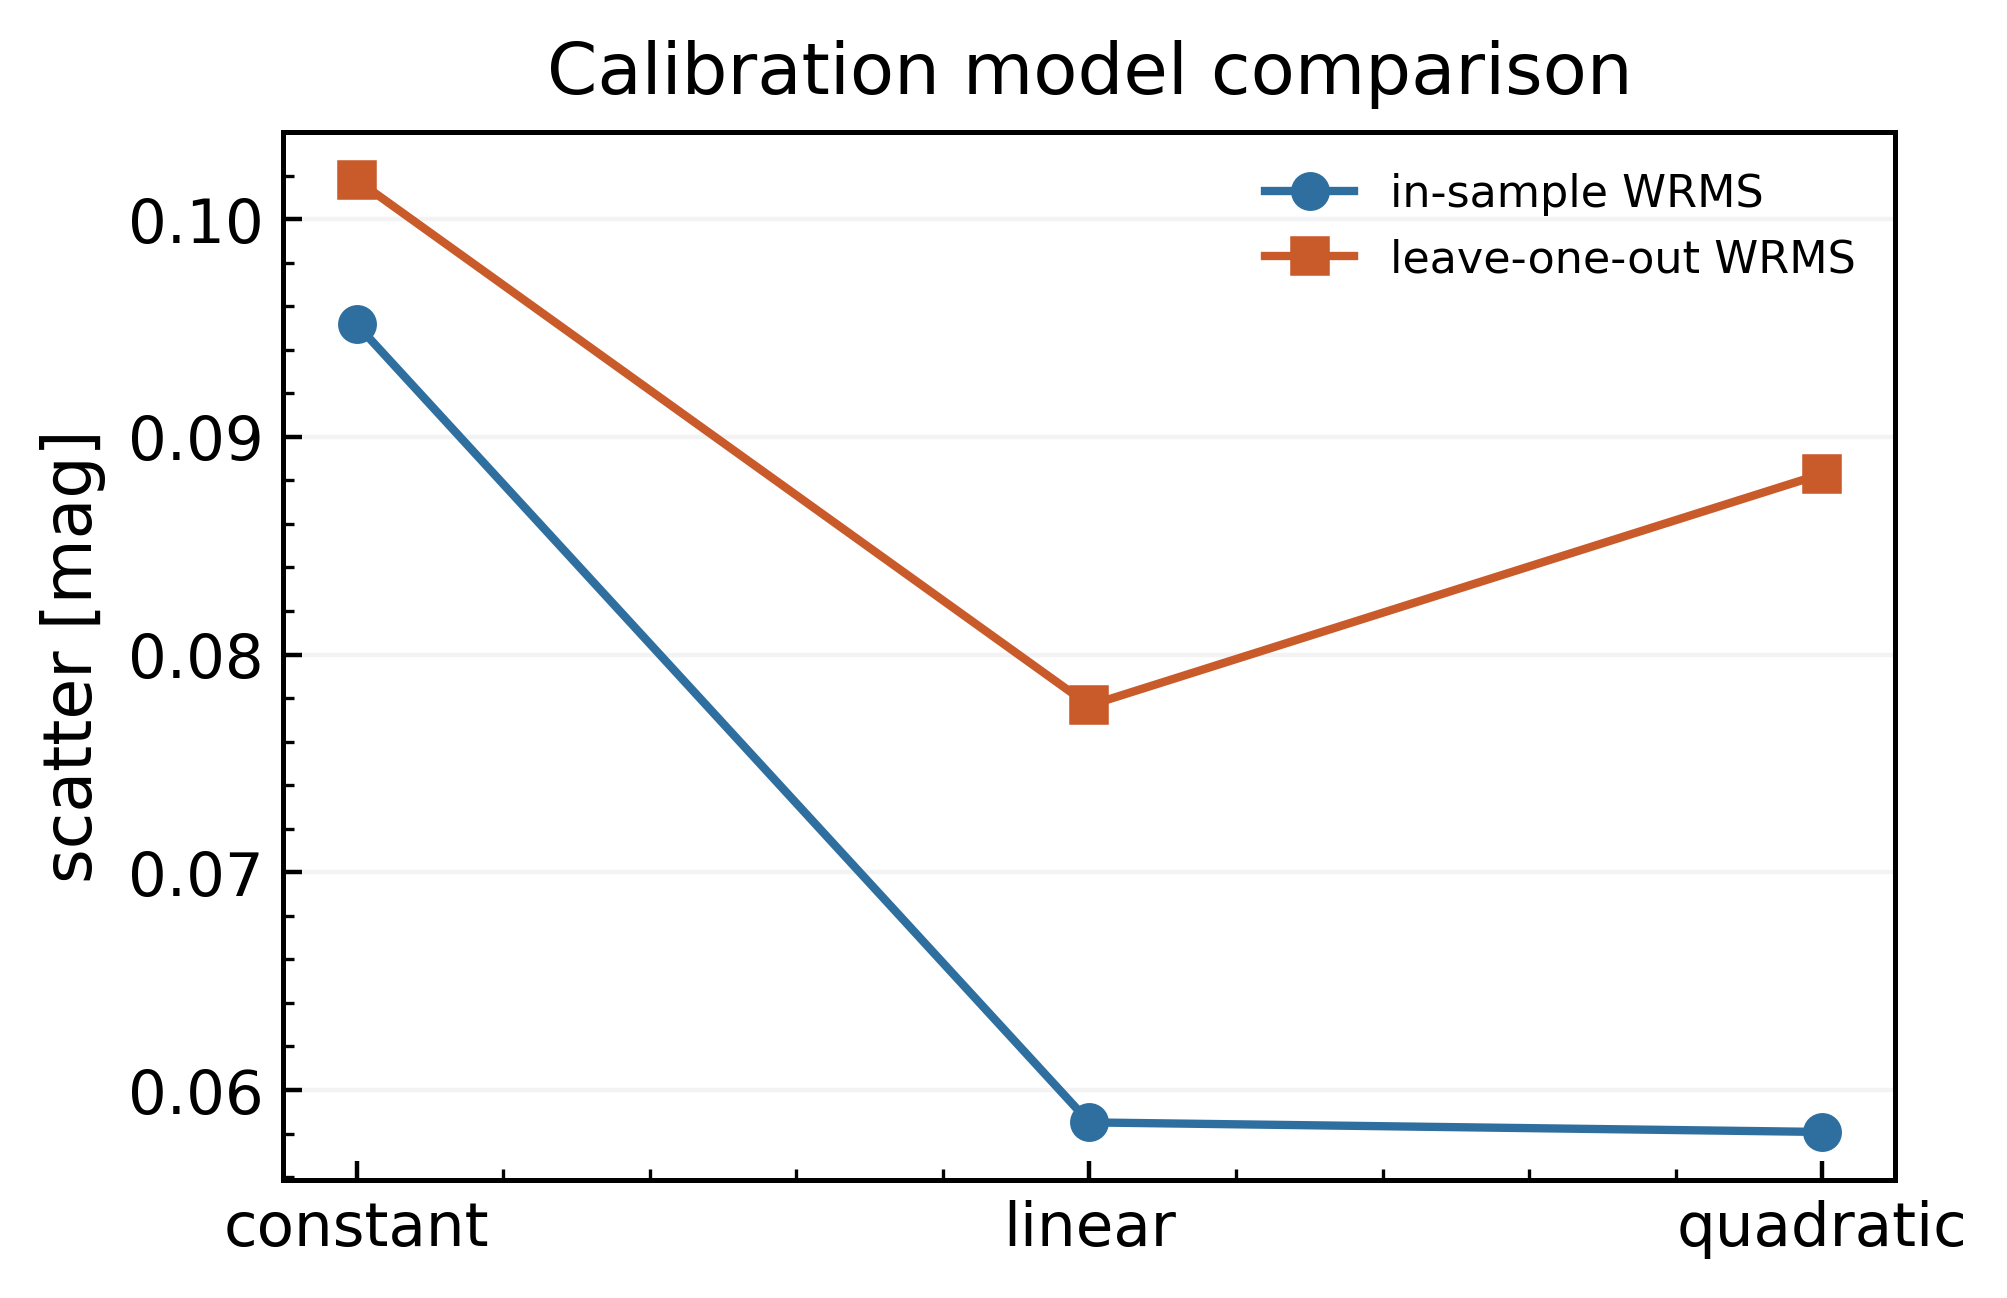

In [30]:
MODEL_COMPARE_CSV = BATCH_DIR / "paper_model_comparison.csv"
MODEL_COMPARE_LOO_CSV = BATCH_DIR / "paper_model_comparison_leave_one_out.csv"

model_calib = pd.read_csv(CALIBRATION_INPUT_CSV).copy()
model_calib["has_absolute_sbf"] = np.isfinite(model_calib["Mbar_150"]) & np.isfinite(model_calib["sigma_Mbar_150"])
model_calib["is_clean"] = model_calib["quality_flag"].eq("clean")
model_fit_df = model_calib[model_calib["has_absolute_sbf"] & model_calib["is_clean"]].copy().reset_index(drop=True)

MODEL_COLOR_PIVOT = 0.40

def design_matrix(color, degree, pivot=MODEL_COLOR_PIVOT):
    x = np.asarray(color, dtype=float) - pivot
    return np.column_stack([x**p for p in range(degree + 1)])

def weighted_poly_fit(df, degree, sigma_int=0.0):
    y = df["Mbar_150"].to_numpy(dtype=float)
    sigma = np.sqrt(df["sigma_Mbar_150"].to_numpy(dtype=float)**2 + sigma_int**2)
    X = design_matrix(df["color_F090W_F150W"], degree)
    w = 1.0 / sigma**2
    xtw = X.T * w
    cov = np.linalg.inv(xtw @ X)
    beta = cov @ (xtw @ y)
    model = X @ beta
    resid = y - model
    n = len(y)
    k = len(beta)
    dof = max(n - k, 1)
    chi2 = float(np.sum((resid / sigma)**2))
    return {
        "degree": degree,
        "beta": beta,
        "cov": cov,
        "model": model,
        "resid": resid,
        "chi2": chi2,
        "chi2_red": chi2 / dof,
        "dof": dof,
        "n": n,
        "k": k,
        "aic": chi2 + 2 * k,
        "bic": chi2 + k * np.log(n),
    }

def predict_poly(fit, color):
    X = design_matrix(color, fit["degree"])
    y = X @ fit["beta"]
    sigma = np.sqrt(np.einsum("ij,jk,ik->i", X, fit["cov"], X))
    return y, sigma

def sigma_int_for_degree(df, degree):
    fit0 = weighted_poly_fit(df, degree, sigma_int=0.0)
    if fit0["chi2_red"] <= 1.0:
        return 0.0
    lo, hi = 0.0, 0.02
    while weighted_poly_fit(df, degree, sigma_int=hi)["chi2_red"] > 1.0:
        hi *= 2
        if hi > 1.0:
            raise RuntimeError(f"Could not bracket sigma_int for degree={degree}")
    for _ in range(64):
        mid = 0.5 * (lo + hi)
        if weighted_poly_fit(df, degree, sigma_int=mid)["chi2_red"] > 1.0:
            lo = mid
        else:
            hi = mid
    return hi

def weighted_rms(values, sigma):
    values = np.asarray(values, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    w = 1.0 / sigma**2
    mean = np.average(values, weights=w)
    return float(np.sqrt(np.average((values - mean)**2, weights=w)))

model_rows = []
loo_rows = []
model_names = {0: "constant", 1: "linear", 2: "quadratic"}

for degree in [0, 1, 2]:
    fit = weighted_poly_fit(model_fit_df, degree, sigma_int=0.0)
    sig_int = sigma_int_for_degree(model_fit_df, degree)
    fit_int = weighted_poly_fit(model_fit_df, degree, sigma_int=sig_int)
    in_sample_wrms = weighted_rms(fit["resid"], model_fit_df["sigma_Mbar_150"])

    loo_resid = []
    loo_sigma = []
    for i, test_row in model_fit_df.iterrows():
        train = model_fit_df.drop(index=i)
        if len(train) <= degree + 1:
            continue
        train_fit = weighted_poly_fit(train, degree, sigma_int=0.0)
        pred, pred_sigma = predict_poly(train_fit, [test_row["color_F090W_F150W"]])
        mu_sbf = test_row["mbar_150"] - pred[0]
        mu_resid = mu_sbf - test_row["mu_lit"]
        sigma_mu = math.sqrt(test_row["sigma_mbar_150"]**2 + pred_sigma[0]**2 + test_row["sigma_mu_lit"]**2 + sig_int**2)
        loo_resid.append(mu_resid)
        loo_sigma.append(sigma_mu)
        loo_rows.append({
            "model": model_names[degree],
            "degree": degree,
            "galaxy": test_row["galaxy"],
            "mu_residual_loo": mu_resid,
            "sigma_mu_residual_loo": sigma_mu,
        })

    row = {
        "model": model_names[degree],
        "degree": degree,
        "n_fit": fit["n"],
        "n_params": fit["k"],
        "Mbar_at_0p40": fit["beta"][0],
        "slope": fit["beta"][1] if degree >= 1 else np.nan,
        "quadratic": fit["beta"][2] if degree >= 2 else np.nan,
        "chi2_red": fit["chi2_red"],
        "aic": fit["aic"],
        "bic": fit["bic"],
        "sigma_int_for_chi2red_1": sig_int,
        "chi2_red_with_sigma_int": fit_int["chi2_red"],
        "in_sample_wrms": in_sample_wrms,
        "loo_wrms": weighted_rms(loo_resid, loo_sigma),
        "loo_plain_rms": float(np.std(loo_resid, ddof=1)),
    }
    model_rows.append(row)

model_compare = pd.DataFrame(model_rows)
model_loo = pd.DataFrame(loo_rows)
model_compare.to_csv(MODEL_COMPARE_CSV, index=False)
model_loo.to_csv(MODEL_COMPARE_LOO_CSV, index=False)

display(model_compare)
print(f"Saved: {MODEL_COMPARE_CSV}")
print(f"Saved: {MODEL_COMPARE_LOO_CSV}")

fig, ax = plt.subplots(figsize=(5.2, 3.4))
x = np.arange(len(model_compare))
ax.plot(x, model_compare["in_sample_wrms"], marker="o", color="#2f6f9f", label="in-sample WRMS")
ax.plot(x, model_compare["loo_wrms"], marker="s", color="#c95b2b", label="leave-one-out WRMS")
ax.set_xticks(x)
ax.set_xticklabels(model_compare["model"])
ax.set_ylabel("scatter [mag]")
ax.set_title("Calibration model comparison", pad=7)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.14)
fig.savefig(FIG_DIR / "paper_model_comparison_scatter.pdf")
fig.savefig(FIG_DIR / "paper_model_comparison_scatter.png")
plt.show()


## Диагностика источников разброса

Проверяем, с чем связаны остатки `mu_SBF - mu_lit`: с цветом, расстоянием, внутренним расхождением inner/outer annuli, ошибкой `P(k)`, PSF, вкладом неразрешённых источников `Pr/P0` и флагами качества.

Эта диагностика нужна не для нового результата, а для интерпретации: если остатки коррелируют с технической величиной, значит ограничение идёт от пайплайна; если с цветом — возможно, линейная цветовая поправка недостаточна; если явной корреляции нет — вероятно, доминируют малая выборка и остаточные systematic на уровне отдельных галактик.


,quantity,n_all,pearson_all,n_clean,pearson_clean
0,color_F090W_F150W,14,-0.195170,10,-0.156930
1,mu_lit,14,-0.216764,10,-0.249295
2,inner_outer_delta,14,0.203870,10,0.570833
3,sigma_Pk_jensen_weighted_annuli,14,0.012058,10,0.186313
4,sigma_PSF_mag,14,0.506138,10,0.218444
5,Pr_over_P0_weighted,14,0.383389,10,-0.032545


Saved: /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/code/sbf2_batch_outputs/paper_residual_diagnostics.csv


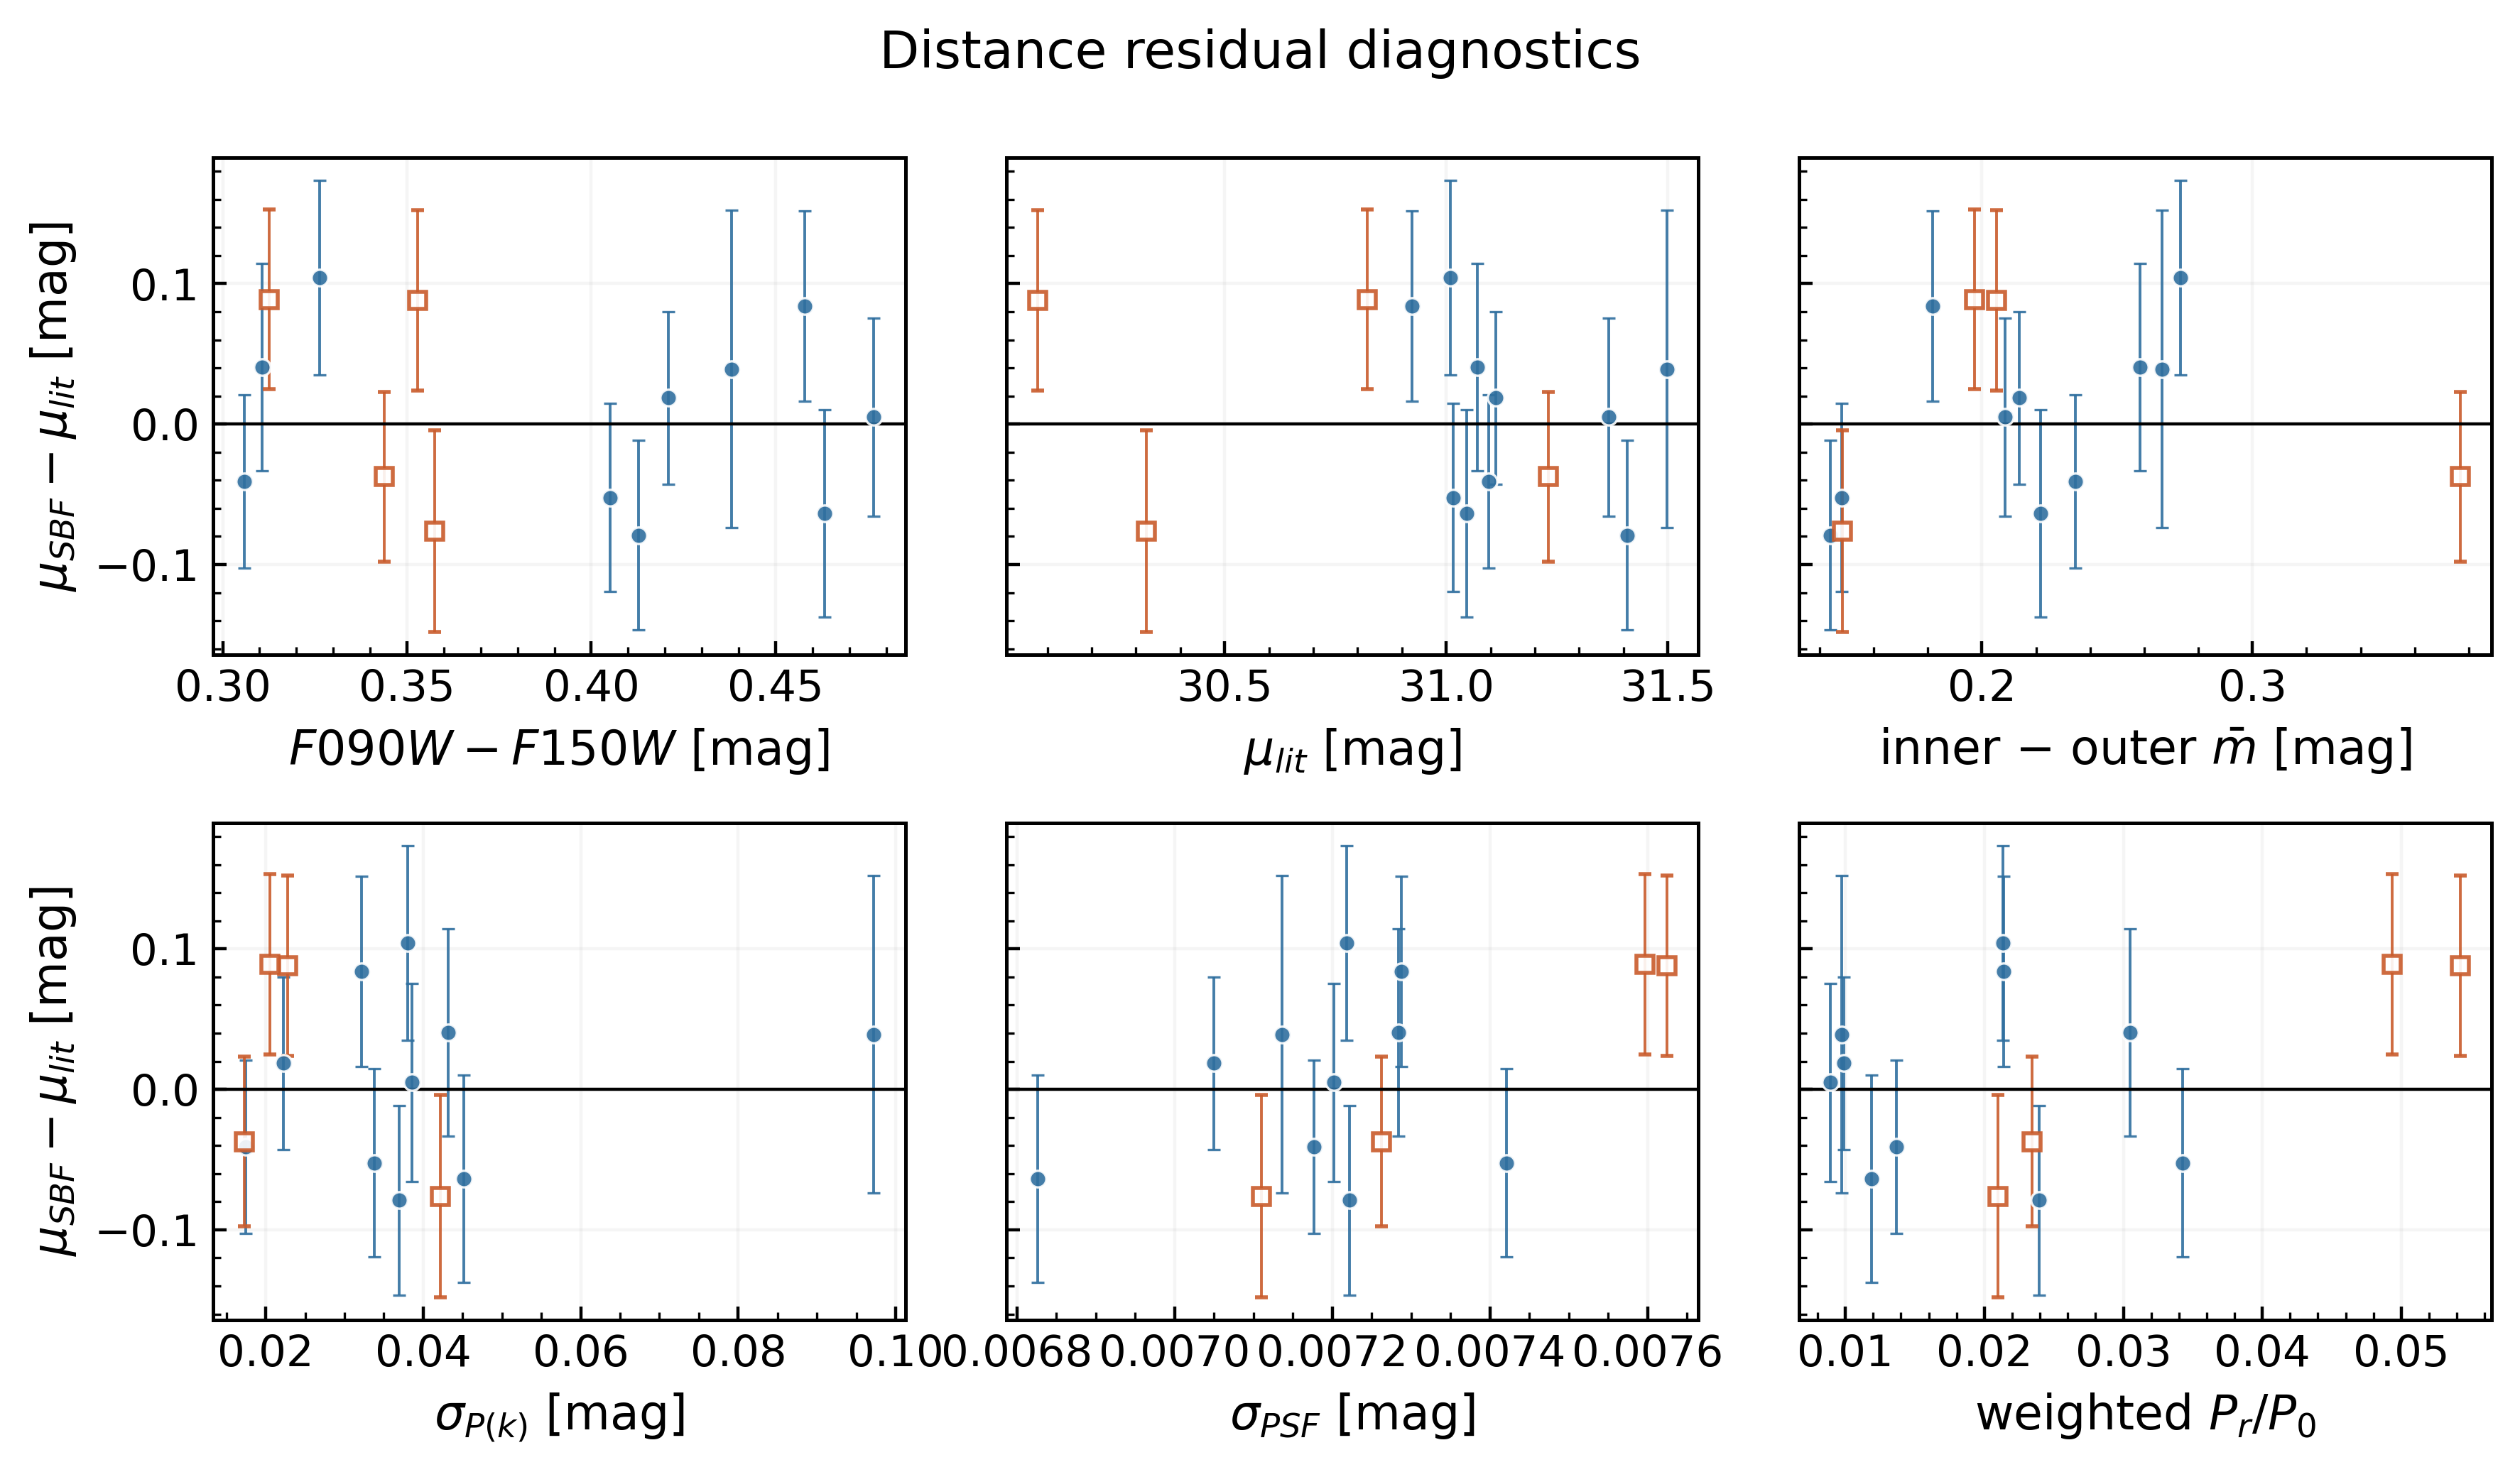

In [31]:
RESIDUAL_DIAGNOSTICS_CSV = BATCH_DIR / "paper_residual_diagnostics.csv"

if "paper_calib" in globals() and "mu_residual_paper" in paper_calib.columns:
    diag_df = paper_calib[paper_plot_mask].copy()
else:
    diag_df = pd.read_csv(BATCH_DIR / "paper_main_sbf_distance_residuals.csv")

diag_candidates = [
    ("color_F090W_F150W", r"$F090W-F150W$ [mag]"),
    ("mu_lit", r"$\mu_{lit}$ [mag]"),
    ("inner_outer_delta", r"inner $-$ outer $\bar m$ [mag]"),
    ("sigma_Pk_jensen_weighted_annuli", r"$\sigma_{P(k)}$ [mag]"),
    ("sigma_PSF_mag", r"$\sigma_{PSF}$ [mag]"),
    ("Pr_over_P0_weighted", r"weighted $P_r/P_0$"),
]

corr_rows = []
for col, label in diag_candidates:
    valid = np.isfinite(diag_df[col]) & np.isfinite(diag_df["mu_residual_paper"])
    clean_valid = valid & diag_df["is_clean"]
    corr_rows.append({
        "quantity": col,
        "n_all": int(valid.sum()),
        "pearson_all": float(diag_df.loc[valid, col].corr(diag_df.loc[valid, "mu_residual_paper"])),
        "n_clean": int(clean_valid.sum()),
        "pearson_clean": float(diag_df.loc[clean_valid, col].corr(diag_df.loc[clean_valid, "mu_residual_paper"])),
    })

corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv(RESIDUAL_DIAGNOSTICS_CSV, index=False)
display(corr_df)
print(f"Saved: {RESIDUAL_DIAGNOSTICS_CSV}")

fig, axes = plt.subplots(2, 3, figsize=(9.0, 5.2), sharey=True)
for ax, (col, label) in zip(axes.ravel(), diag_candidates):
    for is_clean, plot_label in [(True, "clean"), (False, "flagged")]:
        sub = diag_df[diag_df["is_clean"].eq(is_clean)]
        st = PAPER_STYLE[plot_label] if "PAPER_STYLE" in globals() else {
            "color": "#2f6f9f" if is_clean else "#c95b2b",
            "marker": "o" if is_clean else "s",
            "mfc": "#2f6f9f" if is_clean else "white",
            "mec": "white" if is_clean else "#c95b2b",
            "mew": 0.7,
        }
        ax.errorbar(
            sub[col],
            sub["mu_residual_paper"],
            yerr=sub["sigma_mu_residual_paper"],
            fmt=st["marker"],
            ms=4.2,
            capsize=1.6,
            lw=0.7,
            color=st["color"],
            mec=st["mec"],
            mfc=st["mfc"],
            mew=st["mew"],
            alpha=0.9,
        )
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel(label)
    ax.grid(alpha=0.12)

axes[0, 0].set_ylabel(r"$\mu_{SBF} - \mu_{lit}$ [mag]")
axes[1, 0].set_ylabel(r"$\mu_{SBF} - \mu_{lit}$ [mag]")
fig.suptitle("Distance residual diagnostics", y=0.99)
fig.tight_layout()
fig.savefig(FIG_DIR / "paper_residual_diagnostics_grid.pdf")
fig.savefig(FIG_DIR / "paper_residual_diagnostics_grid.png")
plt.show()
